# Samsung Health 분석

원본 설문과 웨어러블 일단위 기록의 전처리 과정은 사전에 실행되어 다음 3개의 최종 데이터로 정리되어 있으며, 이 노트북은 원본 파싱·집계 코드 없이 이 데이터를 불러오는 것에서 시작한다.

- `data/survey_final.csv`: 참여자×주차 단위 정제된 설문 응답 + Stress/CES-D 채점 결과 + gender (웨어러블 연동이 확인된 58명의 id, week 기준 231행 — 전체 설문응답 412건 중 분석표본 후보이며, 이 중 214행에 유효한 웨어러블 기록이 있음)
- `data/wearable_person_week.csv`: 참여자×주차 단위 웨어러블 파생 지표 — 수면시간/질/각성, 걷기빈도/시간, coverage 관련 지표 (id, week 기준 231행)
- `data/wearable_sleep_person.csv`: 참여자 단위 수면시간 습관적 정의 — D-1A 수면시간 분석에 사용 (id 기준 58행)

In [3]:
import pandas as pd
import numpy as np

survey_final = pd.read_csv('data/survey_final.csv')
wearable_person_week = pd.read_csv('data/wearable_person_week.csv')
sleep_person = pd.read_csv('data/wearable_sleep_person.csv')

df_merged = survey_final.merge(wearable_person_week, on=['id', 'week'], how='inner')
df_merged['survey_date'] = pd.to_datetime(df_merged['survey_date'])

assert len(df_merged) == 231, f'행 수 불일치: {len(df_merged)}'

SLEEP_WD_COL = "하루에 보통 몇 시간 주무십니까?_주중(또는 일하는 날)  ___시간"
SLEEP_WE_COL = "하루에 보통 몇 시간 주무십니까?_주말(또는 일하지 않는 날, 일하지 않는 전날)  ___시간"

print('df_merged:', df_merged.shape)
print('sleep_person:', sleep_person.shape)


df_merged: (231, 51)
sleep_person: (58, 7)


## 1. D-1 — 개인 수준 통합 간극모형

같은 단위 4쌍(걷기빈도·걷기시간·주중/주말 수면시간)과 다른 단위 2쌍(수면질·야간각성①)은 "0점이 실제 일치를 의미하는지"가 달라 분리해서 분석한다.

- **D-1A(같은 단위)**: $D^*_{ij}=(S_{ij}-W_{ij})/SD_j(D)$ — signed는 우세 방향, |D*|는 방향과 무관한 불일치 크기로 해석 가능. 혼합모형: $|D^*_{ij}| = \beta_0 + \gamma_j Indicator_j + \beta_1 Stress_i + \beta_2 Gender_i + \beta_3 Coverage_{ij} + u_i + \epsilon_{ij}$ (`gap_std ~ indicator + gender + coverage_ratio + mean_stress/mean_CESD + (1|id)`, M0/M1-S/M1-C/M2).
- **D-1B(다른 단위)**: $R_{ij}=Z(S_{ij})-Z(W_{ij})$ (방법별 z-score 후 차이) — 절대적 과대/과소평가가 아니라 **상대적(순위 기반) 불일치**로만 해석. 인당 관측치가 지표당 1개뿐이라 혼합모형이 아니라 지표별 개별 OLS(HC3 robust SE)로 분석.
- 지표별 품질변수(coverage_ratio, 0~1): 걷기=`pedometer_record_days`/7, 수면시간=B의 유효야간수/가능야간수, 수면질·야간각성①=`match_quality`/7.
- id=80은 성별 결측 — 성별 포함 모형에서는 자동 제외, 성별 제외 민감도 모형에서 별도 확인.
- D-1B는 8개 핵심 검정(2지표×2outcome×{stress,CESD})에 BH-FDR 적용.

In [4]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.showwarning = lambda *args, **kwargs: None  # statsmodels 내부에서 필터가 재설정되어도 경고 출력을 막음
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests

gender_by_id = df_merged[['id', 'gender']].dropna().drop_duplicates(subset=['id']).set_index('id')['gender']
mean_stress_by_id = df_merged.groupby('id')['stress'].mean()
mean_cesd_by_id = df_merged.groupby('id')['cesd_total'].mean()

SLEEP_QUALITY_COL = "전반적인 수면이 질이 어느 정도라고 평가하십니까?"
AWAKE_COL = "당신은 다음의 이유로 잠자는데 얼마나 자주 문제가 있었습니까?_한밤중이나 새벽에 깼다"
WALK_FREQ_COL = "지난 일주일 동안 한번에 적어도 10분 이상 걷는 날은 며칠입니까?※ 출퇴근 또는 등하교, 이동 및 운동을 위해 걷는 것을 모두 포함하여 대답해 주십시오."
WALK_TIME_COL = "지난 일주일 동안 한번에 적어도 10분 이상 걸은 날 중 하루 동안 걷는 시간은 보통 얼마나 됩니까?하루에 _시간 _분※ 첫번째 행에는 시간    두번째 행에는 분_총_분"

MIN_WEEKS = 3  # B와 동일한 최소 주차 기준(ICC(1,4) 근거) - person-level 평균이 1~2주만으로 산출되지 않도록

def build_person_D_walk(survey_col, wearable_col):
    d = df_merged[['id', survey_col, wearable_col, 'pedometer_record_days', 'main_analysis_flag']].copy()
    d = d[d['main_analysis_flag'] == True].dropna(subset=[survey_col, wearable_col])
    d['diff'] = d[survey_col] - d[wearable_col]
    g = d.groupby('id').agg(D=('diff', 'mean'), n_weeks=('diff', 'size'), coverage_ratio=('pedometer_record_days', lambda x: x.mean() / 7))
    g = g[g['n_weeks'] >= MIN_WEEKS]
    return g.reset_index()

d_walkfreq = build_person_D_walk(WALK_FREQ_COL, 'walk_days_10min')
d_walktime = build_person_D_walk(WALK_TIME_COL, 'walk_time_10min')

d_wd_sleep = sleep_person[sleep_person['main_weekday_flag']][['id', 'D_weekday', 'n_weekday_nights_total']].copy()
d_wd_sleep.columns = ['id', 'D', 'cov_raw']
d_wd_sleep['coverage_ratio'] = d_wd_sleep['cov_raw'] / 20

d_we_sleep = sleep_person[sleep_person['main_weekend_flag']][['id', 'D_weekend', 'n_weekend_nights_total']].copy()
d_we_sleep.columns = ['id', 'D', 'cov_raw']
d_we_sleep['coverage_ratio'] = d_we_sleep['cov_raw'] / 8

frames_a = {'걷기빈도': d_walkfreq, '걷기시간': d_walktime, '주중_수면시간': d_wd_sleep, '주말_수면시간': d_we_sleep}
rows_a = []
for name, frame in frames_a.items():
    for _, r in frame.iterrows():
        rows_a.append({'id': r['id'], 'indicator': name, 'D': r['D'], 'coverage_ratio': r['coverage_ratio']})
d1a = pd.DataFrame(rows_a)
sd_by_ind_a = d1a.groupby('indicator')['D'].std()
d1a['D_star'] = d1a.apply(lambda r: r['D'] / sd_by_ind_a[r['indicator']], axis=1)
d1a['absD_star'] = d1a['D_star'].abs()
d1a['gender'] = d1a['id'].map(gender_by_id)
d1a['mean_stress'] = d1a['id'].map(mean_stress_by_id)
d1a['mean_CESD'] = d1a['id'].map(mean_cesd_by_id)

def build_person_SW(survey_col, wearable_col, quality_col='match_quality', quality_max=7):
    d = df_merged[['id', survey_col, wearable_col, quality_col]].dropna(subset=[survey_col, wearable_col])
    g = d.groupby('id').agg(S=(survey_col, 'mean'), W=(wearable_col, 'mean'), n_weeks=(survey_col, 'size'),
                             coverage_ratio=(quality_col, lambda x: x.mean() / quality_max))
    g = g[g['n_weeks'] >= MIN_WEEKS]
    return g.reset_index()

d_sleepq = build_person_SW(SLEEP_QUALITY_COL, 'w_sleep_score')
d_awake = build_person_SW(AWAKE_COL, 'w_awake_sleep')

frames_b = {'수면질': d_sleepq, '야간각성①': d_awake}
rows_b = []
for name, frame in frames_b.items():
    zs = (frame['S'] - frame['S'].mean()) / frame['S'].std()
    zw = (frame['W'] - frame['W'].mean()) / frame['W'].std()
    for i, r in frame.iterrows():
        rows_b.append({'id': r['id'], 'indicator': name, 'Zs': zs.loc[i], 'Zw': zw.loc[i],
                      'R': zs.loc[i] - zw.loc[i], 'coverage_ratio': r['coverage_ratio']})
d1b = pd.DataFrame(rows_b)
d1b['absR'] = d1b['R'].abs()
d1b['gender'] = d1b['id'].map(gender_by_id)
d1b['mean_stress'] = d1b['id'].map(mean_stress_by_id)
d1b['mean_CESD'] = d1b['id'].map(mean_cesd_by_id)

print('D-1A:', d1a.groupby('indicator').size().to_dict())
print('D-1B:', d1b.groupby('indicator').size().to_dict())

D-1A: {'걷기빈도': 55, '걷기시간': 51, '주말_수면시간': 43, '주중_수면시간': 46}
D-1B: {'수면질': 53, '야간각성①': 53}


In [5]:
def fit_mixed(data, dv, extra_terms, label):
    d = data.dropna(subset=[dv, 'gender', 'coverage_ratio', 'mean_stress', 'mean_CESD']).copy()
    d['gender'] = d['gender'].astype(int).astype('category')
    formula = f"{dv} ~ C(indicator) + C(gender) + coverage_ratio" + (" + " + extra_terms if extra_terms else "")
    res = smf.mixedlm(formula, d, groups=d['id']).fit(reml=True)
    print(f'--- {label}: {dv} (n_obs={len(d)}, n_id={d["id"].nunique()}) ---')
    for term in res.params.index:
        if term == 'Group Var':
            continue
        ci = res.conf_int().loc[term]
        print(f'  {term}: coef={res.params[term]:.4f}, 95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={res.pvalues[term]:.4f}')
    return res, d

print('===== D-1A signed D* =====')
fit_mixed(d1a, 'D_star', None, 'M0')
fit_mixed(d1a, 'D_star', 'mean_stress', 'M1-S')
fit_mixed(d1a, 'D_star', 'mean_CESD', 'M1-C')
fit_mixed(d1a, 'D_star', 'mean_stress + mean_CESD', 'M2')

===== D-1A signed D* =====
--- M0: D_star (n_obs=193, n_id=55) ---
  Intercept: coef=2.6058, 95%CI=[1.1600,4.0516], p=0.0004
  C(indicator)[T.걷기시간]: coef=-0.7591, 95%CI=[-1.1320,-0.3863], p=0.0001
  C(indicator)[T.주말_수면시간]: coef=-0.8827, 95%CI=[-1.3354,-0.4300], p=0.0001
  C(indicator)[T.주중_수면시간]: coef=-1.7013, 95%CI=[-2.1997,-1.2029], p=0.0000
  C(gender)[T.2]: coef=0.1969, 95%CI=[-0.1073,0.5010], p=0.2045
  coverage_ratio: coef=-1.6256, 95%CI=[-3.0604,-0.1908], p=0.0264
--- M1-S: D_star (n_obs=193, n_id=55) ---
  Intercept: coef=2.7532, 95%CI=[1.1789,4.3275], p=0.0006
  C(indicator)[T.걷기시간]: coef=-0.7603, 95%CI=[-1.1334,-0.3871], p=0.0001
  C(indicator)[T.주말_수면시간]: coef=-0.8850, 95%CI=[-1.3384,-0.4316], p=0.0001
  C(indicator)[T.주중_수면시간]: coef=-1.7053, 95%CI=[-2.2049,-1.2057], p=0.0000
  C(gender)[T.2]: coef=0.1972, 95%CI=[-0.1088,0.5031], p=0.2065
  coverage_ratio: coef=-1.6470, 95%CI=[-3.0890,-0.2050], p=0.0252
  mean_stress: coef=-0.0594, 95%CI=[-0.3027,0.1839], p=0.6323
--- M1-C:

(<statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x21baf3184c0>,
        id indicator         D  coverage_ratio    D_star  absD_star gender  \
 0     1.0      걷기빈도  1.750000        1.000000  1.224019   1.224019      2   
 1     2.0      걷기빈도  0.750000        0.928571  0.524580   0.524580      2   
 2     3.0      걷기빈도  0.250000        1.000000  0.174860   0.174860      2   
 3     4.0      걷기빈도  1.333333        1.000000  0.932586   0.932586      2   
 4     6.0      걷기빈도  1.000000        1.000000  0.699439   0.699439      1   
 ..    ...       ...       ...             ...       ...        ...    ...   
 190  82.0   주말_수면시간  1.158333        0.750000  0.666435   0.666435      1   
 191  84.0   주말_수면시간  1.568750        1.000000  0.902563   0.902563      2   
 192  89.0   주말_수면시간  0.206250        1.000000  0.118664   0.118664      1   
 193  90.0   주말_수면시간  1.035714        0.875000  0.595887   0.595887      1   
 194  94.0   주말_수면시간  2.020000        0.625000  1.162185 

In [6]:
print('===== D-1A |D*| (불일치 크기) =====')
fit_mixed(d1a, 'absD_star', None, 'M0')
res_m1s, _ = fit_mixed(d1a, 'absD_star', 'mean_stress', 'M1-S')
fit_mixed(d1a, 'absD_star', 'mean_CESD', 'M1-C')
res_m2, d_m2 = fit_mixed(d1a, 'absD_star', 'mean_stress + mean_CESD', 'M2')

===== D-1A |D*| (불일치 크기) =====
--- M0: absD_star (n_obs=193, n_id=55) ---
  Intercept: coef=2.4270, 95%CI=[1.3095,3.5444], p=0.0000
  C(indicator)[T.걷기시간]: coef=-0.5984, 95%CI=[-0.8813,-0.3154], p=0.0000
  C(indicator)[T.주말_수면시간]: coef=-0.5914, 95%CI=[-0.9372,-0.2456], p=0.0008
  C(indicator)[T.주중_수면시간]: coef=-0.7001, 95%CI=[-1.0812,-0.3189], p=0.0003
  C(gender)[T.2]: coef=0.2572, 95%CI=[0.0151,0.4993], p=0.0373
  coverage_ratio: coef=-1.3708, 95%CI=[-2.4789,-0.2626], p=0.0153
--- M1-S: absD_star (n_obs=193, n_id=55) ---
  Intercept: coef=1.8004, 95%CI=[0.6198,2.9811], p=0.0028
  C(indicator)[T.걷기시간]: coef=-0.5942, 95%CI=[-0.8774,-0.3111], p=0.0000
  C(indicator)[T.주말_수면시간]: coef=-0.5859, 95%CI=[-0.9294,-0.2424], p=0.0008
  C(indicator)[T.주중_수면시간]: coef=-0.6863, 95%CI=[-1.0639,-0.3086], p=0.0004
  C(gender)[T.2]: coef=0.2539, 95%CI=[0.0275,0.4802], p=0.0279
  coverage_ratio: coef=-1.2910, 95%CI=[-2.3754,-0.2065], p=0.0196
  mean_stress: coef=0.2587, 95%CI=[0.0789,0.4385], p=0.0048
---

In [7]:
def nakagawa_r2(res):
    # Nakagawa & Schielzeth (2013) marginal/conditional R^2 for MixedLM
    exog = res.model.exog
    fixed_pred = exog @ res.fe_params.values
    var_fixed = np.var(fixed_pred, ddof=0)
    var_random = float(res.cov_re.iloc[0, 0]) if res.cov_re.shape[0] > 0 else 0.0
    var_resid = res.scale
    total = var_fixed + var_random + var_resid
    return var_fixed / total, (var_fixed + var_random) / total

print('===== D-1A 설명력(R^2): marginal(고정효과) vs conditional(+개인차 random intercept) =====')
for dv in ['D_star', 'absD_star']:
    for label, extra in [('M0', None), ('M1-S', 'mean_stress'), ('M1-C', 'mean_CESD'), ('M2', 'mean_stress + mean_CESD')]:
        res, _ = fit_mixed(d1a, dv, extra, label)
        r2m, r2c = nakagawa_r2(res)
        print(f'  [{dv} / {label}] marginal R^2={r2m:.4f}, conditional R^2={r2c:.4f}')

===== D-1A 설명력(R^2): marginal(고정효과) vs conditional(+개인차 random intercept) =====
--- M0: D_star (n_obs=193, n_id=55) ---
  Intercept: coef=2.6058, 95%CI=[1.1600,4.0516], p=0.0004
  C(indicator)[T.걷기시간]: coef=-0.7591, 95%CI=[-1.1320,-0.3863], p=0.0001
  C(indicator)[T.주말_수면시간]: coef=-0.8827, 95%CI=[-1.3354,-0.4300], p=0.0001
  C(indicator)[T.주중_수면시간]: coef=-1.7013, 95%CI=[-2.1997,-1.2029], p=0.0000
  C(gender)[T.2]: coef=0.1969, 95%CI=[-0.1073,0.5010], p=0.2045
  coverage_ratio: coef=-1.6256, 95%CI=[-3.0604,-0.1908], p=0.0264
  [D_star / M0] marginal R^2=0.2125, conditional R^2=0.2523
--- M1-S: D_star (n_obs=193, n_id=55) ---
  Intercept: coef=2.7532, 95%CI=[1.1789,4.3275], p=0.0006
  C(indicator)[T.걷기시간]: coef=-0.7603, 95%CI=[-1.1334,-0.3871], p=0.0001
  C(indicator)[T.주말_수면시간]: coef=-0.8850, 95%CI=[-1.3384,-0.4316], p=0.0001
  C(indicator)[T.주중_수면시간]: coef=-1.7053, 95%CI=[-2.2049,-1.2057], p=0.0000
  C(gender)[T.2]: coef=0.1972, 95%CI=[-0.1088,0.5031], p=0.2065
  coverage_ratio: coef=-

In [8]:
# VIF (M2 실제 분석표본 기준)
X = sm.add_constant(d_m2[['coverage_ratio', 'mean_stress', 'mean_CESD']])
print('VIF (D-1A M2):')
for i, col in enumerate(X.columns):
    if col != 'const':
        print(f'  {col}: {variance_inflation_factor(X.values, i):.3f}')

# 참여자 단위 부트스트랩: |D*| M1-S의 mean_stress 계수
# 주의: 반복 추출된 참여자에게는 원래 id가 아니라 반복별 고유 ID를 부여해야 함
# (원래 id로 그룹핑하면 같은 그룹 라벨 안에 서로 다른 반복이 섞여 수렴 실패율이 높아짐)
np.random.seed(7)
d_boot_base = d1a.dropna(subset=['absD_star', 'gender', 'coverage_ratio', 'mean_stress']).copy()
d_boot_base['gender'] = d_boot_base['gender'].astype(int).astype('category')
ids = d_boot_base['id'].unique()
boot_coefs = []
n_target, max_attempts, attempts = 1000, 3000, 0
while len(boot_coefs) < n_target and attempts < max_attempts:
    attempts += 1
    sample_ids = np.random.choice(ids, size=len(ids), replace=True)
    parts = []
    for rep_i, sid in enumerate(sample_ids):
        sub = d_boot_base[d_boot_base['id'] == sid].copy()
        sub['_boot_id'] = f'{sid}_{rep_i}'  # 반복별 고유 그룹 ID
        parts.append(sub)
    dboot = pd.concat(parts, ignore_index=True)
    try:
        res = smf.mixedlm("absD_star ~ C(indicator) + C(gender) + coverage_ratio + mean_stress",
                           dboot, groups=dboot['_boot_id']).fit(reml=True, method='lbfgs')
        boot_coefs.append(res.params['mean_stress'])
    except Exception:
        continue
boot_coefs = np.array(boot_coefs)
print(f'참여자단위 부트스트랩 mean_stress (|D*| M1-S): 시도 {attempts}회 중 성공 {len(boot_coefs)}회 (성공률 {len(boot_coefs)/attempts*100:.1f}%)')

if len(boot_coefs) / attempts < 0.5:
    print('성공률이 낮아 percentile CI는 선택편향 우려로 추론에 사용하지 않음. 대체 민감도: ID-cluster robust OLS')
    ols_res = smf.ols("absD_star ~ C(indicator) + C(gender) + coverage_ratio + mean_stress", d_boot_base).fit(
        cov_type='cluster', cov_kwds={'groups': d_boot_base['id']})
    ci = ols_res.conf_int().loc['mean_stress']
    print(f"  ID-cluster robust OLS: mean_stress coef={ols_res.params['mean_stress']:.4f}, 95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={ols_res.pvalues['mean_stress']:.4f}")
else:
    print(f'  95% percentile CI: [{np.percentile(boot_coefs, 2.5):.4f}, {np.percentile(boot_coefs, 97.5):.4f}]')

VIF (D-1A M2):
  coverage_ratio: 1.007
  mean_stress: 2.009
  mean_CESD: 2.002


참여자단위 부트스트랩 mean_stress (|D*| M1-S): 시도 3000회 중 성공 296회 (성공률 9.9%)
성공률이 낮아 percentile CI는 선택편향 우려로 추론에 사용하지 않음. 대체 민감도: ID-cluster robust OLS
  ID-cluster robust OLS: mean_stress coef=0.2593, 95%CI=[0.0307,0.4878], p=0.0262


In [9]:
# id=80(성별 결측) 민감도: 성별 제외 + id=80 포함 모형, 동일 스펙(M1-S, M2)으로 비교
def fit_no_gender(data, dv, extra_terms):
    d = data.dropna(subset=[dv, 'coverage_ratio', 'mean_stress', 'mean_CESD']).copy()
    formula = f"{dv} ~ C(indicator) + coverage_ratio" + (" + " + extra_terms if extra_terms else "")
    res = smf.mixedlm(formula, d, groups=d['id']).fit(reml=True)
    return res, len(d), d['id'].nunique()

print('===== id=80 민감도 (성별 제외, id=80 포함) — |D*| =====')
res, n, nid = fit_no_gender(d1a, 'absD_star', 'mean_stress')
ci = res.conf_int().loc['mean_stress']
print(f'M1-S (n_obs={n}, n_id={nid}): mean_stress coef={res.params["mean_stress"]:.4f}, 95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={res.pvalues["mean_stress"]:.4f}')

res2, n2, nid2 = fit_no_gender(d1a, 'absD_star', 'mean_stress + mean_CESD')
ci_s, ci_c = res2.conf_int().loc['mean_stress'], res2.conf_int().loc['mean_CESD']
print(f'M2 (n_obs={n2}, n_id={nid2}): mean_stress coef={res2.params["mean_stress"]:.4f}, p={res2.pvalues["mean_stress"]:.4f} / mean_CESD coef={res2.params["mean_CESD"]:.4f}, p={res2.pvalues["mean_CESD"]:.4f}')

===== id=80 민감도 (성별 제외, id=80 포함) — |D*| =====
M1-S (n_obs=195, n_id=56): mean_stress coef=0.2489, 95%CI=[0.0641,0.4338], p=0.0083
M2 (n_obs=195, n_id=56): mean_stress coef=0.2973, p=0.0273 / mean_CESD coef=-0.0044, p=0.6116


In [10]:
# D-1B: 인당 지표당 관측치 1개 -> 혼합모형 대신 지표별 개별 OLS(HC3)
def ols_hc3(data, dv, extra_terms, with_gender=True):
    d = data.dropna(subset=[dv, 'coverage_ratio', 'mean_stress', 'mean_CESD'] + (['gender'] if with_gender else [])).copy()
    rhs = 'coverage_ratio' + (' + C(gender)' if with_gender else '') + (' + ' + extra_terms if extra_terms else '')
    res = smf.ols(f"{dv} ~ {rhs}", d).fit(cov_type='HC3')
    return res, len(d)

d1b_results = []
for indicator in ['수면질', '야간각성①']:
    sub = d1b[d1b['indicator'] == indicator]
    for outcome in ['R', 'absR']:
        print(f'===== {indicator} / {outcome} =====')
        for label, terms in [('M0', None), ('M1-S', 'mean_stress'), ('M1-C', 'mean_CESD'), ('M2', 'mean_stress + mean_CESD')]:
            res, n = ols_hc3(sub, outcome, terms)
            print(f'--- {label} (n={n}, HC3) ---')
            for term in res.params.index:
                ci = res.conf_int().loc[term]
                print(f'  {term}: coef={res.params[term]:.4f}, 95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={res.pvalues[term]:.4f}')
            if label in ('M1-S', 'M1-C'):
                key_term = 'mean_stress' if label == 'M1-S' else 'mean_CESD'
                d1b_results.append({'indicator': indicator, 'outcome': outcome, 'model': label,
                                     'term': key_term, 'coef': res.params[key_term], 'p': res.pvalues[key_term]})

===== 수면질 / R =====
--- M0 (n=52, HC3) ---
  Intercept: coef=1.0573, 95%CI=[-1.0416,3.1563], p=0.3235
  C(gender)[T.2.0]: coef=0.2991, 95%CI=[-0.5046,1.1029], p=0.4657
  coverage_ratio: coef=-1.6420, 95%CI=[-4.4516,1.1677], p=0.2520
--- M1-S (n=52, HC3) ---
  Intercept: coef=2.6990, 95%CI=[0.2021,5.1959], p=0.0341
  C(gender)[T.2.0]: coef=0.2938, 95%CI=[-0.4384,1.0260], p=0.4316
  coverage_ratio: coef=-1.7452, 95%CI=[-4.4344,0.9441], p=0.2034
  mean_stress: coef=-0.7350, 95%CI=[-1.2551,-0.2149], p=0.0056
--- M1-C (n=52, HC3) ---
  Intercept: coef=1.5108, 95%CI=[-0.5846,3.6062], p=0.1576
  C(gender)[T.2.0]: coef=0.2340, 95%CI=[-0.4999,0.9679], p=0.5320
  coverage_ratio: coef=-1.3753, 95%CI=[-3.8846,1.1341], p=0.2827
  mean_CESD: coef=-0.0506, 95%CI=[-0.1045,0.0033], p=0.0660
--- M2 (n=52, HC3) ---
  Intercept: coef=2.2067, 95%CI=[-0.1754,4.5888], p=0.0694
  C(gender)[T.2.0]: coef=0.2542, 95%CI=[-0.4862,0.9946], p=0.5010
  coverage_ratio: coef=-1.5233, 95%CI=[-4.0834,1.0369], p=0.2436
  

In [11]:
# Results 3.2 "성분분해": 자기보고 Zs와 웨어러블 Zw를 각각 스트레스에 회귀한다.
# D-1B 헤드라인 모형(M1-S)과 동일한 사양(coverage_ratio + C(gender) + mean_stress, HC3)을
# 수면질 지표의 Zs, Zw 각각에 적용한다.
print('===== D-1B 수면질 성분분해: Zs(자기보고), Zw(웨어러블) 각각을 스트레스에 회귀 (사후 탐색적) =====')
sub_sq = d1b[d1b['indicator'] == '수면질']
for dv in ['Zs', 'Zw']:
    res, n = ols_hc3(sub_sq, dv, 'mean_stress')
    print(f'--- {dv} ~ coverage_ratio + C(gender) + mean_stress (n={n}, HC3) ---')
    for term in res.params.index:
        ci = res.conf_int().loc[term]
        print(f'  {term}: coef={res.params[term]:.4f}, 95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={res.pvalues[term]:.4f}')


===== D-1B 수면질 성분분해: Zs(자기보고), Zw(웨어러블) 각각을 스트레스에 회귀 (사후 탐색적) =====
--- Zs ~ coverage_ratio + C(gender) + mean_stress (n=52, HC3) ---
  Intercept: coef=2.0484, 95%CI=[0.8124,3.2843], p=0.0012
  C(gender)[T.2.0]: coef=0.0057, 95%CI=[-0.4750,0.4864], p=0.9815
  coverage_ratio: coef=0.0506, 95%CI=[-1.1303,1.2316], p=0.9330
  mean_stress: coef=-0.9830, 95%CI=[-1.3823,-0.5837], p=0.0000
--- Zw ~ coverage_ratio + C(gender) + mean_stress (n=52, HC3) ---
  Intercept: coef=-0.6506, 95%CI=[-3.2844,1.9832], p=0.6283
  C(gender)[T.2.0]: coef=-0.2881, 95%CI=[-0.9628,0.3866], p=0.4027
  coverage_ratio: coef=1.7958, 95%CI=[-1.2804,4.8720], p=0.2526
  mean_stress: coef=-0.2480, 95%CI=[-0.6454,0.1494], p=0.2212


In [12]:
print('===== D-1B 설명력(R^2, OLS 결정계수) =====')
for indicator in ['수면질', '야간각성①']:
    sub = d1b[d1b['indicator'] == indicator]
    for outcome in ['R', 'absR']:
        for label, terms in [('M0', None), ('M1-S', 'mean_stress'), ('M1-C', 'mean_CESD'), ('M2', 'mean_stress + mean_CESD')]:
            res, n = ols_hc3(sub, outcome, terms)
            print(f'  [{indicator}/{outcome} / {label}] R^2={res.rsquared:.4f}, adj R^2={res.rsquared_adj:.4f} (n={n})')

===== D-1B 설명력(R^2, OLS 결정계수) =====
  [수면질/R / M0] R^2=0.0771, adj R^2=0.0394 (n=52)
  [수면질/R / M1-S] R^2=0.2324, adj R^2=0.1845 (n=52)
  [수면질/R / M1-C] R^2=0.2468, adj R^2=0.1997 (n=52)
  [수면질/R / M2] R^2=0.2679, adj R^2=0.2056 (n=52)
  [수면질/absR / M0] R^2=0.0584, adj R^2=0.0200 (n=52)
  [수면질/absR / M1-S] R^2=0.0594, adj R^2=0.0007 (n=52)
  [수면질/absR / M1-C] R^2=0.0609, adj R^2=0.0022 (n=52)
  [수면질/absR / M2] R^2=0.0700, adj R^2=-0.0091 (n=52)
  [야간각성①/R / M0] R^2=0.0435, adj R^2=0.0045 (n=52)
  [야간각성①/R / M1-S] R^2=0.0507, adj R^2=-0.0086 (n=52)
  [야간각성①/R / M1-C] R^2=0.0875, adj R^2=0.0304 (n=52)
  [야간각성①/R / M2] R^2=0.0956, adj R^2=0.0186 (n=52)
  [야간각성①/absR / M0] R^2=0.0286, adj R^2=-0.0110 (n=52)
  [야간각성①/absR / M1-S] R^2=0.0345, adj R^2=-0.0259 (n=52)
  [야간각성①/absR / M1-C] R^2=0.0355, adj R^2=-0.0248 (n=52)
  [야간각성①/absR / M2] R^2=0.0361, adj R^2=-0.0459 (n=52)


In [13]:
# BH-FDR: 핵심 8개 검정(stress-only, CESD-only x 2지표 x 2outcome)
d1b_res_df = pd.DataFrame(d1b_results)
rej, p_adj, _, _ = multipletests(d1b_res_df['p'], method='fdr_bh')
d1b_res_df['p_fdr'] = p_adj
d1b_res_df['reject_fdr'] = rej
d1b_res_df

,indicator,outcome,model,term,coef,p,p_fdr,reject_fdr
0,수면질,R,M1-S,mean_stress,-0.734981,0.005612,0.044896,True
1,수면질,R,M1-C,mean_CESD,-0.050552,0.066030,0.264119,False
2,수면질,absR,M1-S,mean_stress,0.040685,0.783332,0.783332,False
3,수면질,absR,M1-C,mean_CESD,-0.004140,0.692655,0.783332,False
4,야간각성①,R,M1-S,mean_stress,0.197058,0.592593,0.783332,False
5,야간각성①,R,M1-C,mean_CESD,0.032080,0.193335,0.515561,False
6,야간각성①,absR,M1-S,mean_stress,0.109659,0.553427,0.783332,False
7,야간각성①,absR,M1-C,mean_CESD,0.007800,0.674839,0.783332,False


In [14]:
# id=80 민감도 (성별 제외, id=80 포함) - 동일 스펙(M1-S)으로 비교
print('===== D-1B id=80 민감도 (성별 제외, id=80 포함, M1-S 스펙) =====')
for indicator in ['수면질', '야간각성①']:
    sub = d1b[d1b['indicator'] == indicator]
    for outcome in ['R', 'absR']:
        res, n = ols_hc3(sub, outcome, 'mean_stress', with_gender=False)
        print(f'[{indicator}/{outcome}] n={n}: mean_stress coef={res.params["mean_stress"]:.4f}, p={res.pvalues["mean_stress"]:.4f}')

# 수면질 M2 VIF
sub_sq = d1b[d1b['indicator'] == '수면질'].dropna(subset=['R', 'coverage_ratio', 'mean_stress', 'mean_CESD'])
X = sm.add_constant(sub_sq[['coverage_ratio', 'mean_stress', 'mean_CESD']])
print('\nVIF (D-1B 수면질 M2):')
for i, col in enumerate(X.columns):
    if col != 'const':
        print(f'  {col}: {variance_inflation_factor(X.values, i):.3f}')

===== D-1B id=80 민감도 (성별 제외, id=80 포함, M1-S 스펙) =====
[수면질/R] n=53: mean_stress coef=-0.6880, p=0.0096
[수면질/absR] n=53: mean_stress coef=0.0653, p=0.6719
[야간각성①/R] n=53: mean_stress coef=0.1578, p=0.6534
[야간각성①/absR] n=53: mean_stress coef=0.0994, p=0.6019

VIF (D-1B 수면질 M2):
  coverage_ratio: 1.028
  mean_stress: 2.040
  mean_CESD: 2.031


### D-1 결론 (개인수준 D_i, raw/모형추정 병기)

- **D-1A(같은 단위 4쌍)**: signed $D^*$에는 스트레스·CES-D 효과 없음. **|D\*|(불일치 크기)에는 스트레스가 유의한 양의 관계**를 보였다. 참여자 단위 부트스트랩(반복별 고유 ID로 재구성)은 3,000회 시도 중 296회만 성공(성공률 9.9%)해 성공 표본만의 percentile CI는 선택편향 가능성이 있어 추론에서 제외하고, 사전에 정한 기준에 따라 **ID-cluster robust OLS**를 주 결과로 보고한다: mean_stress coef=0.259, 95%CI[0.031,0.488], p=0.026. 혼합모형(M1-S) 결과는 참고로 병기한다(coef=0.259, 95%CI[0.079,0.439], p=0.0048). CES-D 동시투입(M2)에서도 유지되었다(coef=0.298, p=0.023). person-level 최소 3주 기준 적용 후에도 결과가 유지되고, VIF≈2 수준으로 심각한 공선성은 아니며, id=80 포함 여부에도 강건하다.
- **D-1B(다른 단위 2쌍, 지표별 개별 회귀)**: 방향 일치 확인(수면질 survey↔wearable 상관 +0.20, 둘 다 "높을수록 좋음"으로 일치 — 역전 불필요). **수면질의 상대적 불일치(R)에서만** 스트레스와 유의한 음의 연관(coef=−0.735, 95%CI[−1.255,−0.215], p=0.0056, BH-FDR 생존, 성별/id=80 처리에 강건). $\beta$는 스트레스가 1점 높을 때 자기보고 수면질의 상대적 위치가 웨어러블보다 약 0.74 표준화 단위 낮은 방향으로 이동함을 의미. 다만 M2(CES-D 동시투입) 시 coef가 −0.38 수준(coef=−0.383, p=0.278)으로 줄고 불확실성이 커짐 — **Stress 단독 모형에서는 유의했지만 CES-D와 공유하는 심리적 분산을 보정한 후에는 독립적인 연관성이 명확하지 않았다**(스트레스 고유효과가 확정된 것은 아니다). 야간각성①, |R|(크기)에는 효과 없음.
- CES-D는 D-1A, D-1B 어디에서도 단독으로 유의한 효과 없음 — "효과가 없다"보다 **"명확한 연관성이 검출되지 않았다"**로 표현.
- **표본 기준**: person-level 평균은 최소 관측 주차 기준(`MIN_WEEKS=3`, B와 동일)을 적용해 산출했으며, 위 결과는 이 기준 하에서도 동일하게 유지된다.

**최종 문구**: 동일 단위 지표에서는 평균 스트레스가 높을수록 자기보고–웨어러블 간극의 절대적 크기가 증가하는 연관성이 관찰되었고 CES-D 동시 보정 후에도 유지되었다. 다른 척도를 사용한 지표에서는 수면질의 방향성 있는 상대적 불일치만 스트레스와 관련되었으며, 이는 다중검정 보정 후에도 유지되었다. 그러나 CES-D 동시 보정 후에는 명확하지 않았다. CES-D 자체와 불일치 간의 명확한 연관성은 관찰되지 않았다.

### 1-1. 스트레스 효과의 수면 특이성(specificity) 직접검정

D-1A(같은 단위 4쌍 통합, 스트레스 유의)와 D-2(걷기 별도모형, 스트레스 비유의)를 나란히 놓고 "스트레스 효과가 수면에 특이적인가"를 검토한다. 두 모형을 별도로 적합해 유의성 여부만 비교하는 것은 도메인 간 효과가 통계적으로 다르다는 근거가 되지 못한다 — 동일 모형 안에서 `mean_stress × domain(수면/걷기)` 상호작용을 직접 검정해야 한다.

In [15]:
domain_map = {'걷기빈도': 'walk', '걷기시간': 'walk',
              '주중_수면시간': 'sleep', '주말_수면시간': 'sleep'}
d1a['domain'] = d1a['indicator'].map(domain_map)

d_spec = d1a.dropna(subset=['absD_star', 'gender', 'coverage_ratio', 'mean_stress']).copy()
d_spec['gender'] = d_spec['gender'].astype(int).astype('category')

print('===== 특이성 직접검정: |D*| ~ C(indicator) + mean_stress + mean_stress:C(domain) + coverage_ratio + C(gender) =====')
res_spec = smf.mixedlm(
    "absD_star ~ C(indicator) + mean_stress + mean_stress:C(domain) + coverage_ratio + C(gender)",
    d_spec, groups=d_spec['id']
).fit(reml=True)
print(f"n_obs={len(d_spec)}, n_id={d_spec['id'].nunique()}")
for term in res_spec.params.index:
    if term == 'Group Var':
        continue
    ci = res_spec.conf_int().loc[term]
    flag = ' <- 특이성 상호작용(걷기 vs 수면 기울기 차이)' if 'domain' in term else ''
    print(f'  {term}: coef={res_spec.params[term]:.4f}, 95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={res_spec.pvalues[term]:.4f}{flag}')

print()
print('-- cluster-robust OLS 민감도 --')
ols_spec = smf.ols(
    "absD_star ~ C(indicator) + mean_stress + mean_stress:C(domain) + coverage_ratio + C(gender)",
    d_spec
).fit(cov_type='cluster', cov_kwds={'groups': d_spec['id']})
for term in ['mean_stress', 'mean_stress:C(domain)[T.walk]']:
    if term in ols_spec.params.index:
        ci = ols_spec.conf_int().loc[term]
        print(f'  {term}: coef={ols_spec.params[term]:.4f}, 95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={ols_spec.pvalues[term]:.4f}')


===== 특이성 직접검정: |D*| ~ C(indicator) + mean_stress + mean_stress:C(domain) + coverage_ratio + C(gender) =====
n_obs=193, n_id=55
  Intercept: coef=1.7341, 95%CI=[0.5263,2.9418], p=0.0049
  C(indicator)[T.걷기시간]: coef=-0.5932, 95%CI=[-0.8772,-0.3092], p=0.0000
  C(indicator)[T.주말_수면시간]: coef=-0.3948, 95%CI=[-1.1821,0.3924], p=0.3256
  C(indicator)[T.주중_수면시간]: coef=-0.4973, 95%CI=[-1.2933,0.2987], p=0.2208
  C(gender)[T.2]: coef=0.2563, 95%CI=[0.0299,0.4827], p=0.0265
  mean_stress: coef=0.2107, 95%CI=[-0.0422,0.4635], p=0.1025
  mean_stress:C(domain)[T.walk]: coef=0.0917, 95%CI=[-0.2477,0.4311], p=0.5965 <- 특이성 상호작용(걷기 vs 수면 기울기 차이)
  coverage_ratio: coef=-1.3187, 95%CI=[-2.4094,-0.2280], p=0.0178

-- cluster-robust OLS 민감도 --
  mean_stress: coef=0.2100, 95%CI=[0.0003,0.4198], p=0.0497
  mean_stress:C(domain)[T.walk]: coef=0.0941, 95%CI=[-0.3442,0.5324], p=0.6740


**해석**: 상호작용이 혼합모형·군집강건모형 모두에서 비유의(P=.597, P=.674)하므로, 스트레스-간극 관계가 수면 영역에 특이적이라는 근거는 확인되지 않았다. 다만 이는 "다르지 않다"는 증거가 아니라 "다르다는 증거가 검출되지 않았다"는 의미로만 해석한다.

### 1-2. Coverage/결측 메커니즘 및 IPW 민감도 분석

D-1A M1-S(mean_stress -> |D*|)의 강건성을, 관측 완성도(coverage)에 의한 선택편향 가능성 관점에서 추가로 점검한다. 스트레스가 높은 사람이 D-1A 포함기준(MIN_WEEKS 등)을 충족할 확률 자체가 낮다면, 관측된 mean_stress 효과가 선택된 표본에서만 나타나는 것일 수 있다. 포함확률을 추정해 안정화 역확률가중치(stabilized IPW)를 구성하고, 가중 재적합·극단가중치 절단 민감도를 확인한다.

In [16]:
def build_person_D_walk_full(survey_col, wearable_col):
    d = df_merged[['id', survey_col, wearable_col, 'pedometer_record_days', 'main_analysis_flag']].copy()
    d = d[d['main_analysis_flag'] == True].dropna(subset=[survey_col, wearable_col])
    d['diff'] = d[survey_col] - d[wearable_col]
    g = d.groupby('id').agg(D=('diff', 'mean'), n_weeks=('diff', 'size'),
                             coverage_ratio=('pedometer_record_days', lambda x: x.mean() / 7))
    g['included'] = (g['n_weeks'] >= MIN_WEEKS).astype(int)
    return g.reset_index()

sel_walkfreq = build_person_D_walk_full(WALK_FREQ_COL, 'walk_days_10min')
sel_walkfreq['indicator'] = '걷기빈도'
sel_walktime = build_person_D_walk_full(WALK_TIME_COL, 'walk_time_10min')
sel_walktime['indicator'] = '걷기시간'
sel_wd_sleep = sleep_person[['id', 'main_weekday_flag']].rename(columns={'main_weekday_flag': 'included'}).copy()
sel_wd_sleep['indicator'] = '주중_수면시간'
sel_wd_sleep['included'] = sel_wd_sleep['included'].astype(int)
sel_we_sleep = sleep_person[['id', 'main_weekend_flag']].rename(columns={'main_weekend_flag': 'included'}).copy()
sel_we_sleep['indicator'] = '주말_수면시간'
sel_we_sleep['included'] = sel_we_sleep['included'].astype(int)

sel_all = pd.concat([
    sel_walkfreq[['id', 'indicator', 'included']],
    sel_walktime[['id', 'indicator', 'included']],
    sel_wd_sleep[['id', 'indicator', 'included']],
    sel_we_sleep[['id', 'indicator', 'included']],
], ignore_index=True)
sel_all['mean_stress'] = sel_all['id'].map(mean_stress_by_id)

print('포함 여부 x indicator (포함/전체):')
print(sel_all.groupby('indicator')['included'].agg(['sum', 'count']))

sel_fit = sel_all.dropna(subset=['mean_stress']).copy()
logit_res = smf.logit("included ~ mean_stress + C(indicator)", sel_fit).fit(disp=0)
print()
print('===== 선택모형: P(D-1A 포함) ~ mean_stress + C(indicator) =====')
for term in logit_res.params.index:
    ci = logit_res.conf_int().loc[term]
    print(f'  {term}: coef={logit_res.params[term]:.4f}, 95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={logit_res.pvalues[term]:.4f}')

sel_fit['p_included'] = logit_res.predict(sel_fit)
marginal_rate = sel_fit['included'].mean()
sel_fit['ipw'] = np.where(sel_fit['included'] == 1, marginal_rate / sel_fit['p_included'], np.nan)
print(f"\n안정화 IPW 요약: min={sel_fit['ipw'].min():.3f}, max={sel_fit['ipw'].max():.3f}, "
      f"mean={sel_fit['ipw'].mean():.3f} (포함관측치만)")

print()
print('===== 참여자 군집강건(cluster-robust) SE + Odds Ratio =====')
logit_cr = smf.logit("included ~ mean_stress + C(indicator)", sel_fit).fit(
    disp=0, cov_type='cluster', cov_kwds={'groups': sel_fit['id']})
term = 'mean_stress'
coef = logit_cr.params[term]
ci = logit_cr.conf_int().loc[term]
orv = np.exp(coef)
or_ci = np.exp(ci)
print(f"  mean_stress(스트레스 1~4점 척도, 비표준화 원점수): "
      f"logit coef={coef:.4f}, cluster-robust p={logit_cr.pvalues[term]:.4f}")
print(f"  스트레스 1단위 증가당 포함 Odds Ratio={orv:.3f}, "
      f"95%CI=[{or_ci[0]:.3f},{or_ci[1]:.3f}] (군집강건 SE, id단위 클러스터)")


포함 여부 x indicator (포함/전체):
           sum  count
indicator            
걷기빈도        55     57
걷기시간        51     57
주말_수면시간     43     58
주중_수면시간     46     58

===== 선택모형: P(D-1A 포함) ~ mean_stress + C(indicator) =====
  Intercept: coef=4.9184, 95%CI=[2.8512,6.9857], p=0.0000
  C(indicator)[T.걷기시간]: coef=-1.1873, 95%CI=[-2.8402,0.4656], p=0.1592
  C(indicator)[T.주말_수면시간]: coef=-2.3059, 95%CI=[-3.8444,-0.7675], p=0.0033
  C(indicator)[T.주중_수면시간]: coef=-2.0057, 95%CI=[-3.5623,-0.4492], p=0.0116
  mean_stress: coef=-0.6986, 95%CI=[-1.3217,-0.0754], p=0.0280

안정화 IPW 요약: min=0.860, max=1.450, mean=1.003 (포함관측치만)

===== 참여자 군집강건(cluster-robust) SE + Odds Ratio =====
  mean_stress(스트레스 1~4점 척도, 비표준화 원점수): logit coef=-0.6986, cluster-robust p=0.1229
  스트레스 1단위 증가당 포함 Odds Ratio=0.497, 95%CI=[0.205,1.208] (군집강건 SE, id단위 클러스터)


In [17]:
d1a_w = d1a.merge(sel_fit[['id', 'indicator', 'ipw']], on=['id', 'indicator'], how='left')
d_w = d1a_w.dropna(subset=['absD_star', 'gender', 'coverage_ratio', 'mean_stress', 'ipw']).copy()
d_w['gender'] = d_w['gender'].astype(int).astype('category')

print('===== M1-S 재추정 비교: 무가중 vs IPW vs IPW-절단 =====')
unweighted = smf.ols("absD_star ~ C(indicator) + C(gender) + coverage_ratio + mean_stress", d_w).fit(
    cov_type='cluster', cov_kwds={'groups': d_w['id']})
ci = unweighted.conf_int().loc['mean_stress']
print(f"[무가중(cluster-robust)] mean_stress: coef={unweighted.params['mean_stress']:.4f}, "
      f"95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={unweighted.pvalues['mean_stress']:.4f}")

ipw_res = smf.wls("absD_star ~ C(indicator) + C(gender) + coverage_ratio + mean_stress", d_w,
                   weights=d_w['ipw']).fit(cov_type='cluster', cov_kwds={'groups': d_w['id']})
ci = ipw_res.conf_int().loc['mean_stress']
print(f"[IPW가중] mean_stress: coef={ipw_res.params['mean_stress']:.4f}, "
      f"95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={ipw_res.pvalues['mean_stress']:.4f}")

lo, hi = d_w['ipw'].quantile([0.01, 0.99])
d_w['ipw_trunc'] = d_w['ipw'].clip(lo, hi)
ipw_trunc_res = smf.wls("absD_star ~ C(indicator) + C(gender) + coverage_ratio + mean_stress", d_w,
                         weights=d_w['ipw_trunc']).fit(cov_type='cluster', cov_kwds={'groups': d_w['id']})
ci = ipw_trunc_res.conf_int().loc['mean_stress']
print(f"[IPW가중+1%/99% 절단] mean_stress: coef={ipw_trunc_res.params['mean_stress']:.4f}, "
      f"95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={ipw_trunc_res.pvalues['mean_stress']:.4f}")
print(f"\n절단 범위: [{lo:.3f}, {hi:.3f}] (원래 범위 [{d_w['ipw'].min():.3f}, {d_w['ipw'].max():.3f}])")


===== M1-S 재추정 비교: 무가중 vs IPW vs IPW-절단 =====


[무가중(cluster-robust)] mean_stress: coef=0.2593, 95%CI=[0.0307,0.4878], p=0.0262
[IPW가중] mean_stress: coef=0.2624, 95%CI=[0.0391,0.4856], p=0.0212
[IPW가중+1%/99% 절단] mean_stress: coef=0.2624, 95%CI=[0.0391,0.4856], p=0.0212

절단 범위: [0.860, 1.450] (원래 범위 [0.860, 1.450])


**해석**: 포함확률과 스트레스 간 오즈비가 비유의(OR=0.497, P=.123)하고, IPW 가중 후에도 계수가 무가중 모형과 거의 동일(β=0.262 vs 0.259)하므로, 관측 완성도에 따른 표본선택이 스트레스-간극 관계를 설명하지 못하는 것으로 보인다.

### 1-3. 걷기 정의 정렬 임계값(threshold) 곡선

걷기빈도의 ICC가 10분 기준 정렬로 0.10->0.39로 개선된 것을 단일 임계값 결과로만 두지 않고, 0/5/10/15/20분 연속보행 기준을 모두 비교해 일치도가 임계값에 따라 어떻게 변하는지 곡선으로 제시한다. 동일한 person-week 표본(main_analysis_flag)을 유지하고, 걷기빈도/걷기시간을 별도로 분석한다. 사후적으로 가장 좋은 임계값을 고르는 것이 목적이 아니라, 설문이 명시하는 10분 기준을 주분석으로 유지하면서 나머지를 곡선으로 함께 보고한다.

---
**[이관 안내]** 본 셀은 원본 데이터를 참조하므로 해당 버전에서는 재현 불가능합니다. 아래 출력은 원본 데이터가 있던 환경에서 이미 실행되어 논문에 반영된 결과이며, 분석 결론에 영향을 주지 않는 검증/민감도분석입니다.

In [ ]:
r"""
# 전체 병합세션(임계값 없음) 재스캔 - eligible_df(>=10분 필터된)와 독립적으로
all_session_rows = []
for _, _row in id_folder_map.iterrows():
    sid, fname = _row['id'], _row['files']
    root, folder = find_subject_folder(sid, fname)
    if folder is None:
        continue
    ex_path = os.path.join(root, folder, 'exercise.csv')
    if not os.path.exists(ex_path):
        continue
    ex = pd.read_csv(ex_path, encoding='cp949')
    if COL_TYPE not in ex.columns:
        continue
    walking = ex[ex[COL_TYPE] == 1001].copy()
    if len(walking) == 0:
        continue
    walking['start_time'] = pd.to_datetime(walking[COL_START], errors='coerce')
    walking['end_time'] = pd.to_datetime(walking[COL_END], errors='coerce')
    walking = walking.dropna(subset=['start_time', 'end_time'])
    merged, _ = merge_overlapping_intervals(walking[['start_time', 'end_time', 'source_type']])
    for m in merged:
        duration_min = (m['end_time'] - m['start_time']).total_seconds() / 60
        all_session_rows.append({'id': sid, 'date': m['start_time'].date(), 'duration_min': duration_min})

all_sessions_df = pd.DataFrame(all_session_rows)
all_sessions_df['date'] = pd.to_datetime(all_sessions_df['date'])
print(f'전체 병합세션(임계값 없음): {len(all_sessions_df)}건, {all_sessions_df["id"].nunique()}명')

THRESHOLDS = [0, 5, 10, 15, 20]

def build_walk_agg(threshold):
    elig = all_sessions_df[all_sessions_df['duration_min'] >= threshold]
    rows = []
    for _, r in df_merged[['id', 'week', 'survey_date']].iterrows():
        sid, wk, sdate = r['id'], r['week'], r['survey_date']
        sub = elig[elig['id'] == sid]
        win = sub[(sub['date'] >= sdate - pd.Timedelta(days=7)) & (sub['date'] <= sdate - pd.Timedelta(days=1))]
        walk_days = win['date'].nunique()
        walk_time = win['duration_min'].sum() / walk_days if walk_days > 0 else np.nan
        rows.append({'id': sid, 'week': wk, f'walk_days_{threshold}': walk_days, f'walk_time_{threshold}': walk_time})
    return pd.DataFrame(rows)

agg_by_thr = {t: build_walk_agg(t) for t in THRESHOLDS}

dm_all = df_merged[['id', 'week', 'survey_date', 'main_analysis_flag', 'pedometer_record_days',
                     WALK_FREQ_COL, WALK_TIME_COL]].copy()
for t in THRESHOLDS:
    dm_all = dm_all.merge(agg_by_thr[t], on=['id', 'week'])
dm_all = dm_all[dm_all['main_analysis_flag'] == True]
print(f'분석 표본(main_analysis_flag) person-week n={len(dm_all)}')
"""

In [ ]:
r"""
def icc_2_1_point(x, y):
    n = len(x); k = 2
    data = np.column_stack([x, y])
    gm = data.mean(); rm = data.mean(axis=1); cm = data.mean(axis=0)
    SSR = k * np.sum((rm - gm) ** 2); SSC = n * np.sum((cm - gm) ** 2)
    SST = np.sum((data - gm) ** 2); SSE = SST - SSR - SSC
    MSR = SSR / (n - 1); MSC = SSC / (k - 1); MSE = SSE / ((n - 1) * (k - 1))
    return (MSR - MSE) / (MSR + (k - 1) * MSE + k * (MSC - MSE) / n)

def person_level_multi(df, survey_col, wcols, weight_col='pedometer_record_days'):
    d = df[['id', survey_col, weight_col] + wcols].dropna(subset=[survey_col] + wcols)
    def wm(g):
        w = g[weight_col].clip(lower=0.01)
        out = {'S': (g[survey_col] * w).sum() / w.sum()}
        for c in wcols:
            out[c] = (g[c] * w).sum() / w.sum()
        return pd.Series(out)
    return d.groupby('id').apply(wm, include_groups=False).dropna()

freq_wcols = [f'walk_days_{t}' for t in THRESHOLDS]
time_wcols = [f'walk_time_{t}' for t in THRESHOLDS]
wide_freq = person_level_multi(dm_all, WALK_FREQ_COL, freq_wcols)
wide_time = person_level_multi(dm_all, WALK_TIME_COL, time_wcols)

def curve_stats(wide, wcols, thresholds, tol_margin):
    S = wide['S'].values
    rows = []
    for t, wc in zip(thresholds, wcols):
        W = wide[wc].values
        diff = W - S
        mean_diff = diff.mean(); mae = np.abs(diff).mean(); sd = diff.std(ddof=1)
        tol = (np.abs(diff) <= tol_margin).mean() * 100
        icc = icc_2_1_point(S, W)
        rows.append({'threshold': t, 'n': len(wide), 'mean_diff': mean_diff, 'mae': mae, 'icc': icc,
                     'tol_pct': tol, 'loa_lo': mean_diff - 1.96 * sd, 'loa_hi': mean_diff + 1.96 * sd})
    return pd.DataFrame(rows)

def joint_bootstrap(wide, wcols, thresholds, ref=10, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(wide); idx_all = wide.index.values
    icc_boot = {t: [] for t in thresholds}
    diff_vs_ref_boot = {t: [] for t in thresholds}
    for _ in range(n_boot):
        samp = rng.choice(idx_all, size=n, replace=True)
        sub = wide.loc[samp]
        S = sub['S'].values
        iccs = {}
        for t, wc in zip(thresholds, wcols):
            W = sub[wc].values
            iccs[t] = np.nan if (S.std() == 0 or W.std() == 0) else icc_2_1_point(S, W)
            icc_boot[t].append(iccs[t])
        refval = iccs[ref]
        for t in thresholds:
            diff_vs_ref_boot[t].append(iccs[t] - refval)
    summary = []
    for t in thresholds:
        arr = np.array(icc_boot[t]); arr = arr[~np.isnan(arr)]
        lo, hi = np.percentile(arr, [2.5, 97.5])
        darr = np.array(diff_vs_ref_boot[t]); darr = darr[~np.isnan(darr)]
        dlo, dhi = (np.percentile(darr, [2.5, 97.5]) if len(darr) > 0 else (np.nan, np.nan))
        summary.append({'threshold': t, 'icc_boot_lo': lo, 'icc_boot_hi': hi,
                         f'diff_vs_{ref}min_lo': dlo, f'diff_vs_{ref}min_hi': dhi})
    return pd.DataFrame(summary)

freq_stats = curve_stats(wide_freq, freq_wcols, THRESHOLDS, tol_margin=1)
freq_boot = joint_bootstrap(wide_freq, freq_wcols, THRESHOLDS)
time_stats = curve_stats(wide_time, time_wcols, THRESHOLDS, tol_margin=30)
time_boot = joint_bootstrap(wide_time, time_wcols, THRESHOLDS)

print('===== 걷기빈도: 임계값별 일치도 곡선 (허용오차=±1일) =====')
print(freq_stats.merge(freq_boot, on='threshold').to_string(index=False))
print()
print('===== 걷기시간: 임계값별 일치도 곡선 (허용오차=±30분) =====')
print(time_stats.merge(time_boot, on='threshold').to_string(index=False))
"""

In [ ]:
r"""
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, stats, boot, label in [(axes[0], freq_stats, freq_boot, 'Walking frequency'),
                                 (axes[1], time_stats, time_boot, 'Walking time')]:
    merged_tb = stats.merge(boot, on='threshold')
    ax.plot(merged_tb['threshold'], merged_tb['icc'], marker='o', color='tab:blue')
    ax.fill_between(merged_tb['threshold'], merged_tb['icc_boot_lo'], merged_tb['icc_boot_hi'], alpha=0.2, color='tab:blue')
    ax.axvline(10, color='red', linestyle='--', linewidth=1, label='Main analysis (10min)')
    ax.set_xlabel('Continuous-walking duration threshold (min)')
    ax.set_ylabel('ICC(2,1) with survey')
    ax.set_title(label)
    ax.legend()
plt.tight_layout()
plt.savefig('results/analysis5_threshold_curve.png', dpi=120)
print('플롯 저장 완료')
"""

## 2. D-2 — 걷기 person×week 간극모형

걷기빈도·걷기시간은 person-level로 접지 않고 person×week 그대로 분석 (걷기는 주 단위 시간창이 개념적으로 타당하기 때문). 두 지표는 **별도 모형이 주 분석**이며, 적층모형(상호작용 포함)은 보조로만 사용.

- 결과변수: 주차별 signed $D^*=(S_{it}-W_{it})/SD(D)$, $|D^*|$
- 품질변수: `pedometer_record_days` (개인 간 `coverage_between` / 개인 내 `coverage_within`으로 분해)
- Stress: 개인 평균(`mean_stress`)을 주 효과로 사용 — 문항이 "평소"를 묻기 때문에 주차별 편차(`stress_within`)는 탐색적으로만
- CES-D: 개인 간(`CESD_between`)·개인 내(`CESD_within`)로 분해 — 문항이 "지난 1주일"을 묻기 때문에 둘 다 본 분석에 포함
- 랜덤효과: `(1|id)`. 두 지표를 적층한 `(1|id)+(1|id:week)` 모형은 상호작용 포함 시에만 보조로 사용
- BH-FDR: 사전 지정 8개 검정(mean_stress, CESD_between × 2지표 × 2outcome)에 적용

In [21]:
WALK_FREQ_COL = "지난 일주일 동안 한번에 적어도 10분 이상 걷는 날은 며칠입니까?※ 출퇴근 또는 등하교, 이동 및 운동을 위해 걷는 것을 모두 포함하여 대답해 주십시오."
WALK_TIME_COL = "지난 일주일 동안 한번에 적어도 10분 이상 걸은 날 중 하루 동안 걷는 시간은 보통 얼마나 됩니까?하루에 _시간 _분※ 첫번째 행에는 시간    두번째 행에는 분_총_분"

def build_d2_indicator(survey_col, wearable_col, name):
    total_pw = len(df_merged)
    d = df_merged[['id', 'week', survey_col, wearable_col, 'pedometer_record_days', 'main_analysis_flag',
                    'stress', 'cesd_total']].copy()
    after_flag = (d['main_analysis_flag'] == True).sum()
    d = d[d['main_analysis_flag'] == True].dropna(subset=[survey_col, wearable_col])
    after_dropna = len(d)

    d['D'] = d[survey_col] - d[wearable_col]
    d['D_star'] = d['D'] / d['D'].std()
    d['absD_star'] = d['D_star'].abs()
    d['gender'] = d['id'].map(gender_by_id)
    d['mean_stress'] = d['id'].map(mean_stress_by_id)
    d['mean_CESD'] = d['id'].map(mean_cesd_by_id)
    d['CESD_between'] = d['mean_CESD']
    d['CESD_within'] = d['cesd_total'] - d['mean_CESD']
    d['stress_within'] = d['stress'] - d['mean_stress']
    cov_between = d.groupby('id')['pedometer_record_days'].transform('mean')
    d['coverage_between'] = cov_between
    d['coverage_within'] = d['pedometer_record_days'] - cov_between
    d['indicator'] = name

    print(f'[{name}] 전체 person-week {total_pw} -> main_analysis_flag(>=6/7) {after_flag} -> 설문·웨어러블 결측 제외 {after_dropna} (id={d["id"].nunique()}명)')
    return d

d2_freq = build_d2_indicator(WALK_FREQ_COL, 'walk_days_10min', '걷기빈도')
d2_time = build_d2_indicator(WALK_TIME_COL, 'walk_time_10min', '걷기시간')

[걷기빈도] 전체 person-week 231 -> main_analysis_flag(>=6/7) 218 -> 설문·웨어러블 결측 제외 218 (id=57명)
[걷기시간] 전체 person-week 231 -> main_analysis_flag(>=6/7) 218 -> 설문·웨어러블 결측 제외 203 (id=57명)


In [22]:
def fit_mixed_d2(data, dv, rhs, label):
    d = data.dropna(subset=[dv, 'gender'] + [t.strip() for t in rhs.split('+')]).copy()
    d['gender'] = d['gender'].astype(int).astype('category')
    res = smf.mixedlm(f"{dv} ~ C(gender) + {rhs}", d, groups=d['id']).fit(reml=True)
    print(f'--- {label} (n_obs={len(d)}, n_id={d["id"].nunique()}) ---')
    for term in res.params.index:
        if term == 'Group Var':
            continue
        ci = res.conf_int().loc[term]
        print(f'  {term}: coef={res.params[term]:.4f}, 95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={res.pvalues[term]:.4f}')
    return res, d

print('===== 개별 혼합모형 (단순 pedometer_record_days 1항) =====')
for label_ind, dset in [('걷기빈도', d2_freq), ('걷기시간', d2_time)]:
    for dv in ['D_star', 'absD_star']:
        print(f'--- {label_ind} / {dv} ---')
        fit_mixed_d2(dset, dv, 'pedometer_record_days', 'M0')
        fit_mixed_d2(dset, dv, 'pedometer_record_days + mean_stress', 'M1-S')
        fit_mixed_d2(dset, dv, 'pedometer_record_days + mean_CESD', 'M1-C')

===== 개별 혼합모형 (단순 pedometer_record_days 1항) =====
--- 걷기빈도 / D_star ---
--- M0 (n_obs=214, n_id=56) ---
  Intercept: coef=3.6085, 95%CI=[-0.7964,8.0134], p=0.1084
  C(gender)[T.2]: coef=0.2295, 95%CI=[-0.1566,0.6157], p=0.2440
  pedometer_record_days: coef=-0.4230, 95%CI=[-1.0538,0.2079], p=0.1888
--- M1-S (n_obs=214, n_id=56) ---
  Intercept: coef=3.5363, 95%CI=[-0.8978,7.9705], p=0.1180
  C(gender)[T.2]: coef=0.2299, 95%CI=[-0.1594,0.6191], p=0.2471
  pedometer_record_days: coef=-0.4269, 95%CI=[-1.0591,0.2053], p=0.1857
  mean_stress: coef=0.0463, 95%CI=[-0.2641,0.3568], p=0.7699
--- M1-C (n_obs=214, n_id=56) ---
  Intercept: coef=3.6798, 95%CI=[-0.7214,8.0811], p=0.1013
  C(gender)[T.2]: coef=0.2270, 95%CI=[-0.1563,0.6103], p=0.2457
  pedometer_record_days: coef=-0.4086, 95%CI=[-1.0391,0.2220], p=0.2041
  mean_CESD: coef=-0.0139, 95%CI=[-0.0341,0.0063], p=0.1769
--- 걷기빈도 / absD_star ---
--- M0 (n_obs=214, n_id=56) ---
  Intercept: coef=5.0909, 95%CI=[1.4559,8.7259], p=0.0061
  C(gen

In [23]:
FULL_M2 = 'mean_stress + CESD_between + CESD_within + coverage_between + coverage_within'

print('===== CES-D·coverage between/within 분해 최종 M2 =====')
key_results = []
final_models = {}
for label_ind, dset in [('걷기빈도', d2_freq), ('걷기시간', d2_time)]:
    for dv in ['D_star', 'absD_star']:
        print(f'--- {label_ind} / {dv} ---')
        res, d_used = fit_mixed_d2(dset, dv, FULL_M2, 'M2_full')
        final_models[(label_ind, dv)] = (res, d_used)
        for term in ['mean_stress', 'CESD_between', 'CESD_within', 'coverage_between', 'coverage_within']:
            key_results.append({'indicator': label_ind, 'outcome': dv, 'term': term,
                                 'coef': res.params[term], 'p': res.pvalues[term]})

===== CES-D·coverage between/within 분해 최종 M2 =====
--- 걷기빈도 / D_star ---
--- M2_full (n_obs=214, n_id=56) ---
  Intercept: coef=5.2522, 95%CI=[-7.7715,18.2758], p=0.4293
  C(gender)[T.2]: coef=0.2255, 95%CI=[-0.1536,0.6046], p=0.2437
  mean_stress: coef=0.3617, 95%CI=[-0.0557,0.7791], p=0.0894
  CESD_between: coef=-0.0300, 95%CI=[-0.0574,-0.0026], p=0.0321
  CESD_within: coef=-0.0191, 95%CI=[-0.0497,0.0115], p=0.2219
  coverage_between: coef=-0.7177, 95%CI=[-2.5968,1.1614], p=0.4541
  coverage_within: coef=-0.3717, 95%CI=[-1.0405,0.2971], p=0.2760
--- 걷기빈도 / absD_star ---
--- M2_full (n_obs=214, n_id=56) ---
  Intercept: coef=8.3714, 95%CI=[-1.3344,18.0771], p=0.0909
  C(gender)[T.2]: coef=0.0495, 95%CI=[-0.2334,0.3325], p=0.7316
  mean_stress: coef=0.3718, 95%CI=[0.0594,0.6842], p=0.0197
  CESD_between: coef=-0.0205, 95%CI=[-0.0409,-0.0000], p=0.0495
  CESD_within: coef=-0.0181, 95%CI=[-0.0436,0.0074], p=0.1646
  coverage_between: coef=-1.1416, 95%CI=[-2.5420,0.2587], p=0.1101
  cover

In [24]:
print('===== D-2 설명력(R^2): marginal vs conditional (M0=coverage만, M2_full=전체) =====')
for label_ind, dset in [('걷기빈도', d2_freq), ('걷기시간', d2_time)]:
    for dv in ['D_star', 'absD_star']:
        res0, _ = fit_mixed_d2(dset, dv, 'pedometer_record_days', 'M0(R^2 비교용)')
        r2m0, r2c0 = nakagawa_r2(res0)
        res_full, _ = final_models[(label_ind, dv)]
        r2m2, r2c2 = nakagawa_r2(res_full)
        print(f'  [{label_ind}/{dv}] M0: marginal={r2m0:.4f}, conditional={r2c0:.4f} | M2_full: marginal={r2m2:.4f}, conditional={r2c2:.4f}')

===== D-2 설명력(R^2): marginal vs conditional (M0=coverage만, M2_full=전체) =====
--- M0(R^2 비교용) (n_obs=214, n_id=56) ---
  Intercept: coef=3.6085, 95%CI=[-0.7964,8.0134], p=0.1084
  C(gender)[T.2]: coef=0.2295, 95%CI=[-0.1566,0.6157], p=0.2440
  pedometer_record_days: coef=-0.4230, 95%CI=[-1.0538,0.2079], p=0.1888
  [걷기빈도/D_star] M0: marginal=0.0193, conditional=0.3695 | M2_full: marginal=0.0668, conditional=0.3888
--- M0(R^2 비교용) (n_obs=214, n_id=56) ---
  Intercept: coef=5.0909, 95%CI=[1.4559,8.7259], p=0.0061
  C(gender)[T.2]: coef=0.0526, 95%CI=[-0.2396,0.3447], p=0.7244
  pedometer_record_days: coef=-0.5921, 95%CI=[-1.1129,-0.0714], p=0.0258
  [걷기빈도/absD_star] M0: marginal=0.0208, conditional=0.3055 | M2_full: marginal=0.0782, conditional=0.3272
--- M0(R^2 비교용) (n_obs=199, n_id=56) ---
  Intercept: coef=-0.1856, 95%CI=[-4.1489,3.7778], p=0.9269
  C(gender)[T.2]: coef=0.2980, 95%CI=[-0.1560,0.7519], p=0.1983
  pedometer_record_days: coef=0.0427, 95%CI=[-0.5222,0.6076], p=0.8821
  [걷기시

In [25]:
print('===== BH-FDR (사전지정 8개: mean_stress, CESD_between x 2지표 x 2outcome) =====')
key_df = pd.DataFrame(key_results)
fam = key_df[key_df['term'].isin(['mean_stress', 'CESD_between'])].copy()
rej, p_adj, _, _ = multipletests(fam['p'], method='fdr_bh')
fam['p_fdr'] = p_adj
fam['reject_fdr'] = rej
fam

===== BH-FDR (사전지정 8개: mean_stress, CESD_between x 2지표 x 2outcome) =====


,indicator,outcome,term,coef,p,p_fdr,reject_fdr
0,걷기빈도,D_star,mean_stress,0.361700,0.089416,0.143066,False
1,걷기빈도,D_star,CESD_between,-0.029964,0.032119,0.128475,False
5,걷기빈도,absD_star,mean_stress,0.371797,0.019653,0.128475,False
6,걷기빈도,absD_star,CESD_between,-0.020487,0.049537,0.132098,False
10,걷기시간,D_star,mean_stress,0.435262,0.082184,0.143066,False
11,걷기시간,D_star,CESD_between,-0.015948,0.337042,0.385191,False
15,걷기시간,absD_star,mean_stress,0.231395,0.280383,0.373844,False
16,걷기시간,absD_star,CESD_between,0.001044,0.941467,0.941467,False


In [26]:
# Leave-one-participant-out: 걷기빈도 |D*| M2 (가장 눈에 띄었던 조합)
res_freq_abs, d_freq_abs = final_models[('걷기빈도', 'absD_star')]
loo_rows = []
for excl in d_freq_abs['id'].unique():
    dsub = d_freq_abs[d_freq_abs['id'] != excl]
    try:
        r = smf.mixedlm(f"absD_star ~ C(gender) + {FULL_M2}", dsub, groups=dsub['id']).fit(reml=True)
        loo_rows.append({'excluded_id': excl, 'stress_coef': r.params['mean_stress'], 'stress_p': r.pvalues['mean_stress'],
                          'cesd_b_coef': r.params['CESD_between'], 'cesd_b_p': r.pvalues['CESD_between']})
    except Exception:
        continue
loo_df = pd.DataFrame(loo_rows)
print(f'Leave-one-out (걷기빈도 |D*| M2), n={len(loo_df)}')
print(f"stress_coef 항상 양수: {(loo_df['stress_coef']>0).mean()*100:.1f}%, p<0.05 유지: {(loo_df['stress_p']<0.05).mean()*100:.1f}%, range=[{loo_df['stress_coef'].min():.3f},{loo_df['stress_coef'].max():.3f}]")
print(f"CESD_between 항상 음수: {(loo_df['cesd_b_coef']<0).mean()*100:.1f}%, p<0.05 유지: {(loo_df['cesd_b_p']<0.05).mean()*100:.1f}%, range=[{loo_df['cesd_b_coef'].min():.3f},{loo_df['cesd_b_coef'].max():.3f}]")

Leave-one-out (걷기빈도 |D*| M2), n=56
stress_coef 항상 양수: 100.0%, p<0.05 유지: 98.2%, range=[0.315,0.427]
CESD_between 항상 음수: 100.0%, p<0.05 유지: 41.1%, range=[-0.024,-0.017]


In [27]:
# ID-cluster robust OLS 민감도 (걷기빈도 |D*| M2)
ols_res = smf.ols(f"absD_star ~ C(gender) + {FULL_M2}", d_freq_abs).fit(cov_type='cluster', cov_kwds={'groups': d_freq_abs['id']})
print('ID-cluster robust OLS (걷기빈도 |D*| M2):')
for term in ['mean_stress', 'CESD_between']:
    ci = ols_res.conf_int().loc[term]
    print(f'  {term}: coef={ols_res.params[term]:.4f}, 95%CI=[{ci[0]:.4f},{ci[1]:.4f}], p={ols_res.pvalues[term]:.4f}')

ID-cluster robust OLS (걷기빈도 |D*| M2):
  mean_stress: coef=0.3933, 95%CI=[0.0915,0.6951], p=0.0106
  CESD_between: coef=-0.0212, 95%CI=[-0.0354,-0.0070], p=0.0035


### D-2 결론

- **걷기시간**: 심리적 특성이나 센서 관측강도와의 명확한 연관성이 검출되지 않았다.
- **걷기시간 vs 걷기빈도 coverage**: 분해하지 않은 센서 기록일 수(`pedometer_record_days`)가 많을수록 걷기빈도 간극의 크기가 작은 연관성이 관찰되었다. 그러나 개인 간(`coverage_between`)·개인 내(`coverage_within`) 효과로 분해했을 때 어느 한 성분에 명확하게 귀속되지는 않았다.
- **CES-D의 개인 내 효과**: `CESD_within`(주차별 편차)은 어떤 조합에서도 유의하지 않았다 — CES-D 효과는 개인 간 효과에 해당한다.
- **Stress/CES-D 동시투입 (걷기빈도)**: 개별모형에서는 각각 비유의했으나, 동시 투입 시 반대 방향의 조건부 연관성이 나타났다(mean_stress 양, CESD_between 음). Stress의 계수 방향은 leave-one-out 전체(56명)에서 안정적이었고(p<0.05 유지율 98.2%), ID-cluster robust OLS에서도 유지되었다(p=0.011). 반면 CESD_between은 방향은 항상 음수였으나 유의성 유지율이 41.1%로 낮았다. **사전 지정한 BH-FDR 8개 검정에서는 어느 것도 생존하지 못했다** — 따라서 이 조건부 패턴은 탐색적 결과로만 해석한다.

**최종 문구**: 걷기시간 간극에서는 심리적 특성이나 센서 관측강도와의 명확한 연관성이 검출되지 않았다. 걷기빈도에서는 센서 기록일이 많을수록 불일치 크기가 작은 경향이 나타났으나, 이를 개인 간 또는 개인 내 효과 중 하나로 명확히 귀속하기는 어려웠다. Stress와 CES-D를 동시에 투입했을 때 반대 방향의 조건부 연관성이 나타났으며 Stress의 계수 방향은 영향력 분석에서 안정적이었다. 그러나 해당 결과는 다중검정 보정을 통과하지 못했으므로 탐색적 결과로 해석하였다.

# 분석 — 전체 6쌍

6개 비교쌍(수면질·야간각성①·걷기빈도·걷기시간·주중/주말 수면시간)을 대상으로 분석한다. 고강도 운동 2쌍은 설문-웨어러블 방향이 모순되어 제외했고, 야간각성②는 야간각성①과 중복되는 보조 지표라 제외했다.

**웨어러블 윈도우 정의**: 각 설문 응답일 직전 7일(`[-7일, -1일]`)의 웨어러블 기록을 해당 응답과 대응시킨다.

## Step 1. 분석 데이터셋 구축
- **person×week**: `df_merged`(웨어러블 연동 후보 231행)의 구조를 유지하며, Step 5 혼합효과모형은 지표별로 설문·웨어러블이 모두 유효한 관측치만 사용한다(available-case).
- **인별(person-level, 일치도 분석용)**: id별로 유효 주차를 `match_quality`(윈도우 내 실측 웨어러블 일수; 걷기는 보수계 기록일수 `pedometer_record_days`)로 가중평균 — 커버리지가 좋은 주차에 더 큰 비중을 줌. 설문·웨어러블 둘 다 결측이 아닌 주차만 사용(pairwise). D-1(스트레스–간극) 분석의 개인 대표값은 D-1 절에서 별도로 구성한다(수면의 질·야간각성①은 유효 주차의 단순평균, 최소 3주).

In [28]:
PAIRS = {
    '수면질': {
        'survey_col': '전반적인 수면이 질이 어느 정도라고 평가하십니까?',
        'wearable_col': 'w_sleep_score',
        'same_unit': False,
    },
    '야간각성①': {
        'survey_col': '당신은 다음의 이유로 잠자는데 얼마나 자주 문제가 있었습니까?_한밤중이나 새벽에 깼다',
        'wearable_col': 'w_awake_sleep',
        'same_unit': False,
    },
    '걷기빈도': {
        'survey_col': '지난 일주일 동안 한번에 적어도 10분 이상 걷는 날은 며칠입니까?※ 출퇴근 또는 등하교, 이동 및 운동을 위해 걷는 것을 모두 포함하여 대답해 주십시오.',
        'wearable_col': 'walk_days_10min',  # 설문과 동일 개념(연속 10분 이상 걸은 날짜 수)으로 재구성한 지표
        'same_unit': True,  # 설문과 동일하게 "지난 7일 중 연속 10분 이상 걸은 날짜 수"(0~7일)를 측정해 단위/범위/0점이 일치
        'weight_col': 'pedometer_record_days',  # A 단계 결론: match_quality는 걷기 지표의 실제 관측 완전성을 과소평가 -> 이 지표엔 pedometer_record_days가 올바른 품질변수
        'require_main_analysis_flag': True,  # D-1과 동일 기준: pedometer_record_days>=6인 person-week만 집계에 사용 (가중치가 0이 되는 것을 구조적으로 방지)
    },
    '걷기시간': {
        'survey_col': '지난 일주일 동안 한번에 적어도 10분 이상 걸은 날 중 하루 동안 걷는 시간은 보통 얼마나 됩니까?하루에 _시간 _분※ 첫번째 행에는 시간    두번째 행에는 분_총_분',
        'wearable_col': 'walk_time_10min',  # 연속 10분 이상 걷기 적격일의 평균 시간으로 재구성한 지표
        'same_unit': True,
        'weight_col': 'pedometer_record_days',
        'require_main_analysis_flag': True,
    },
    '주중_수면시간': {
        'survey_col': '하루에 보통 몇 시간 주무십니까?_주중(또는 일하는 날)  ___시간',
        'wearable_col': 'w_weekday_sleep_hr',
        'same_unit': True,
    },
    '주말_수면시간': {
        'survey_col': '하루에 보통 몇 시간 주무십니까?_주말(또는 일하지 않는 날, 일하지 않는 전날)  ___시간',
        'wearable_col': 'w_weekend_sleep_hr',
        'same_unit': True,
    },
}


def build_person_level(df, survey_col, wearable_col, weight_col='match_quality'):
    """id별로 유효 주차(설문·웨어러블 둘 다 결측 아님)를 weight_col로 가중평균.
    weight_col 합이 0(유효 가중치 없음 = 품질 기준상 대표값을 못 만드는 상태)인 사람은
    NaN + aggregation_flag='no_positive_weight'로 표시하고 단순평균으로 대체하지 않음 -
    임의 대체는 품질 기준상 제외돼야 할 관측치를 다시 포함시키는 결과가 되기 때문.
    걷기 지표는 호출 전에 main_analysis_flag(>=6/7)로 미리 필터링해 가중치가 0이 되는
    상황 자체를 구조적으로 방지함 (PAIRS의 require_main_analysis_flag 참고).
    """
    valid = df[['id', survey_col, wearable_col, weight_col]].dropna(subset=[survey_col, wearable_col])

    def weighted_mean(g):
        w = g[weight_col]
        wsum = w.sum()
        if not np.isfinite(wsum) or wsum <= 0:
            return pd.Series({'survey_value': np.nan, 'wearable_value': np.nan,
                               'n_weeks': len(g), 'aggregation_flag': 'no_positive_weight'})
        return pd.Series({
            'survey_value': (g[survey_col] * w).sum() / wsum,
            'wearable_value': (g[wearable_col] * w).sum() / wsum,
            'n_weeks': len(g), 'aggregation_flag': 'ok',
        })

    return valid.groupby('id').apply(weighted_mean, include_groups=False).reset_index()


PAIR_LABELS = {
    '수면질': 'Sleep Quality',
    '야간각성①': 'Night Awakening (freq)',
    '걷기빈도': 'Walk Frequency',
    '걷기시간': 'Walk Time',
    '주중_수면시간': 'Weekday Sleep',
    '주말_수면시간': 'Weekend Sleep',
}

MIN_WEEKS_PERSON = 3  # D-1과 동일한 최소 주차 기준 (person-level 대표값 안정성)

person_datasets = {}
for pair_name, spec in PAIRS.items():
    src_df = df_merged[df_merged['main_analysis_flag'] == True] if spec.get('require_main_analysis_flag') else df_merged
    pdf = build_person_level(src_df, spec['survey_col'], spec['wearable_col'],
                              weight_col=spec.get('weight_col', 'match_quality'))
    n_no_weight = (pdf['aggregation_flag'] == 'no_positive_weight').sum()
    pdf = pdf.dropna(subset=['survey_value', 'wearable_value'])  # no_positive_weight 등 결측은 pairwise 제외 (단순평균 대체 안 함)
    if spec.get('require_main_analysis_flag'):
        pdf = pdf[pdf['n_weeks'] >= MIN_WEEKS_PERSON]
    person_datasets[pair_name] = pdf
    flag_note = f' (가중치 0 제외 {n_no_weight}명)' if n_no_weight > 0 else ''
    print(f"{pair_name}: {len(pdf)}명{flag_note}")

수면질: 57명
야간각성①: 57명
걷기빈도: 55명
걷기시간: 51명
주중_수면시간: 56명
주말_수면시간: 54명


## Step 2. 기술통계 및 시각적 점검
설문·웨어러블 각각의 평균/중앙값/표준편차/범위는 6쌍 전체 계산. 시각화(산점도+차이분포)는 의미가 큰 **주중/주말 수면시간 2쌍만** — 나머지는 글로 정리.

In [29]:
desc_rows = []
for pair_name, pdf in person_datasets.items():
    for col in ['survey_value', 'wearable_value']:
        s = pdf[col]
        desc_rows.append({
            'pair': pair_name, 'source': col,
            'n': s.count(), 'mean': s.mean(), 'median': s.median(),
            'sd': s.std(), 'min': s.min(), 'max': s.max(),
        })

desc_table = pd.DataFrame(desc_rows).round(2)
desc_table

,pair,source,n,mean,median,sd,min,max
0,수면질,survey_value,57,3.29,3.00,0.74,1.62,5.00
1,수면질,wearable_value,57,64.67,64.96,7.53,37.00,76.88
2,야간각성①,survey_value,57,2.19,1.95,0.99,1.00,4.00
3,야간각성①,wearable_value,57,38.79,39.12,12.57,10.00,64.92
4,걷기빈도,survey_value,55,5.45,5.75,1.45,0.75,7.00
5,걷기빈도,wearable_value,55,3.88,4.00,1.67,0.52,6.75
6,걷기시간,survey_value,51,51.40,45.00,37.84,7.50,240.00
7,걷기시간,wearable_value,51,38.44,34.72,16.83,16.02,101.04
8,주중_수면시간,survey_value,56,6.25,6.19,1.05,3.98,9.00
9,주중_수면시간,wearable_value,56,5.92,6.05,1.55,1.02,8.63


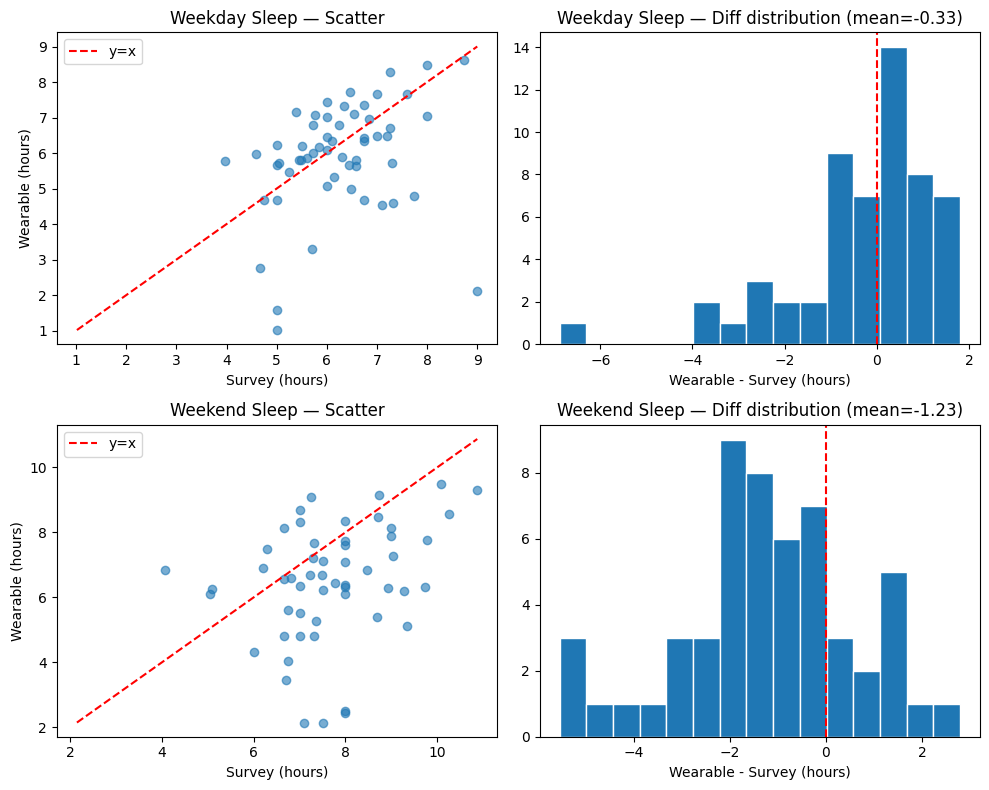

In [30]:
import matplotlib.pyplot as plt

sleep_pairs = {k: v for k, v in person_datasets.items() if k in ('주중_수면시간', '주말_수면시간')}

fig, axes = plt.subplots(len(sleep_pairs), 2, figsize=(10, 4 * len(sleep_pairs)))

for row, (pair_name, pdf) in enumerate(sleep_pairs.items()):
    label = PAIR_LABELS.get(pair_name, pair_name)
    ax_scatter, ax_diff = axes[row]

    lo = min(pdf['survey_value'].min(), pdf['wearable_value'].min())
    hi = max(pdf['survey_value'].max(), pdf['wearable_value'].max())
    ax_scatter.scatter(pdf['survey_value'], pdf['wearable_value'], alpha=0.6)
    ax_scatter.plot([lo, hi], [lo, hi], 'r--', label='y=x')
    ax_scatter.set_xlabel('Survey (hours)')
    ax_scatter.set_ylabel('Wearable (hours)')
    ax_scatter.set_title(f'{label} — Scatter')
    ax_scatter.legend()

    diff = pdf['wearable_value'] - pdf['survey_value']
    ax_diff.hist(diff, bins=15, edgecolor='white')
    ax_diff.axvline(0, color='r', linestyle='--')
    ax_diff.set_xlabel('Wearable - Survey (hours)')
    ax_diff.set_title(f'{label} — Diff distribution (mean={diff.mean():.2f})')

plt.tight_layout()
plt.savefig('results/step3_sleep_scatter_diff.png', dpi=150)
plt.show()

## Step 3. 동일 단위 4쌍 일치도 분석
순서: 평균 차이·MAE → Bland-Altman(평균 편향·95% LoA·비례편향) → 절대일치형 ICC(2,1). 평균편향·LoA·ICC의 95% CI는 참여자 단위 부트스트랩(3,000회)으로 추정한다. **같은 단위로 직접 비교 가능한 4쌍만** — 걷기빈도, 걷기시간, 주중/주말 수면시간. (걷기빈도는 재구성 지표 `walk_days_10min` 사용 — 설문과 동일하게 "지난 7일 중 연속 10분 이상 걸은 날짜 수, 0~7일"을 측정해 단위·범위·0점이 일치하므로 same_unit=True로 분류.)

In [31]:
import numpy as np
from scipy import stats as sps


def icc_2_1_point(x, y):
    """ICC(2,1) two-way mixed, absolute agreement, single measure (Shrout & Fleiss, 1979)"""
    n = len(x)
    k = 2
    data = np.column_stack([x, y])
    grand_mean = data.mean()
    row_means = data.mean(axis=1)
    col_means = data.mean(axis=0)

    SSR = k * np.sum((row_means - grand_mean) ** 2)
    SSC = n * np.sum((col_means - grand_mean) ** 2)
    SST = np.sum((data - grand_mean) ** 2)
    SSE = SST - SSR - SSC

    MSR = SSR / (n - 1)
    MSC = SSC / (k - 1)
    MSE = SSE / ((n - 1) * (k - 1))

    return (MSR - MSE) / (MSR + (k - 1) * MSE + k * (MSC - MSE) / n)


def bootstrap_ci(x, y, func, n_boot=3000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(x)
    point = func(x, y)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        bx, by = x[idx], y[idx]
        if bx.std() == 0 or by.std() == 0:
            continue
        boots.append(func(bx, by))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi


# Methods 2.4에 명시된 평균편향과 LoA 각각의 95% CI(참여자단위 부트스트랩 3,000회)를 산출한다.
def bootstrap_bias_loa_ci(x, y, n_boot=3000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(x)
    bias_boots, loa_lo_boots, loa_hi_boots = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        bx, by = x[idx], y[idx]
        bdiff = by - bx
        bmean, bsd = bdiff.mean(), bdiff.std(ddof=1)
        bias_boots.append(bmean)
        loa_lo_boots.append(bmean - 1.96 * bsd)
        loa_hi_boots.append(bmean + 1.96 * bsd)
    bias_ci = np.percentile(bias_boots, [2.5, 97.5])
    loa_lo_ci = np.percentile(loa_lo_boots, [2.5, 97.5])
    loa_hi_ci = np.percentile(loa_hi_boots, [2.5, 97.5])
    return bias_ci, loa_lo_ci, loa_hi_ci


same_unit_pairs = {name: pdf for name, pdf in person_datasets.items() if PAIRS[name]['same_unit']}

agreement_results = []
for pair_name, pdf in same_unit_pairs.items():
    # 방어: person_datasets 구성 단계에서 이미 결측 제외했지만, 분석 직전에도 한 번 더 확인
    # (한 사람의 비유한값이 ICC/상관 계산 전체를 NaN으로 오염시키는 것을 방지)
    valid_pair = np.isfinite(pdf['survey_value']) & np.isfinite(pdf['wearable_value'])
    n_excluded = (~valid_pair).sum()
    pdf_valid = pdf[valid_pair]
    x = pdf_valid['survey_value'].values
    y = pdf_valid['wearable_value'].values
    n = len(x)
    if n_excluded > 0:
        print(f'[{pair_name}] 비유한값 {n_excluded}건 제외 (pairwise)')

    diff = y - x
    mean_diff = diff.mean()
    mae = np.abs(diff).mean()
    sd_diff = diff.std(ddof=1)
    loa_lo, loa_hi = mean_diff - 1.96 * sd_diff, mean_diff + 1.96 * sd_diff

    mean_xy = (x + y) / 2
    _, prop_bias_p = sps.pearsonr(mean_xy, diff)

    icc_pt, icc_lo, icc_hi = bootstrap_ci(x, y, icc_2_1_point)
    bias_ci, loa_lo_ci, loa_hi_ci = bootstrap_bias_loa_ci(x, y)

    agreement_results.append({
        'pair': pair_name, 'n': n,
        'mean_diff': round(mean_diff, 3), 'MAE': round(mae, 3),
        'bias_CI': f'[{bias_ci[0]:.3f}, {bias_ci[1]:.3f}]',
        'LoA_low': round(loa_lo, 3), 'LoA_high': round(loa_hi, 3),
        'LoA_low_CI': f'[{loa_lo_ci[0]:.3f}, {loa_lo_ci[1]:.3f}]',
        'LoA_high_CI': f'[{loa_hi_ci[0]:.3f}, {loa_hi_ci[1]:.3f}]',
        'prop_bias_p': round(prop_bias_p, 4),
        'ICC': round(icc_pt, 3), 'ICC_CI': f'[{icc_lo:.3f}, {icc_hi:.3f}]',
    })

agreement_table = pd.DataFrame(agreement_results)
agreement_table

,pair,n,mean_diff,MAE,bias_CI,LoA_low,LoA_high,LoA_low_CI,LoA_high_CI,prop_bias_p,ICC,ICC_CI
0,걷기빈도,55,-1.568,1.723,"[-1.930, -1.215]",-4.356,1.219,"[-4.974, -3.637]","[0.634, 1.786]",0.2083,0.391,"[0.242, 0.533]"
1,걷기시간,51,-12.961,23.311,"[-25.374, -3.582]",-89.536,63.613,"[-137.937, -44.882]","[29.529, 93.667]",0.0000,0.102,"[-0.120, 0.507]"
2,주중_수면시간,56,-0.333,1.115,"[-0.775, 0.058]",-3.450,2.783,"[-4.737, -2.203]","[2.039, 3.489]",0.0028,0.275,"[-0.068, 0.556]"
3,주말_수면시간,54,-1.226,1.759,"[-1.715, -0.736]",-4.921,2.468,"[-5.829, -3.926]","[1.696, 3.178]",0.0195,0.224,"[0.057, 0.383]"


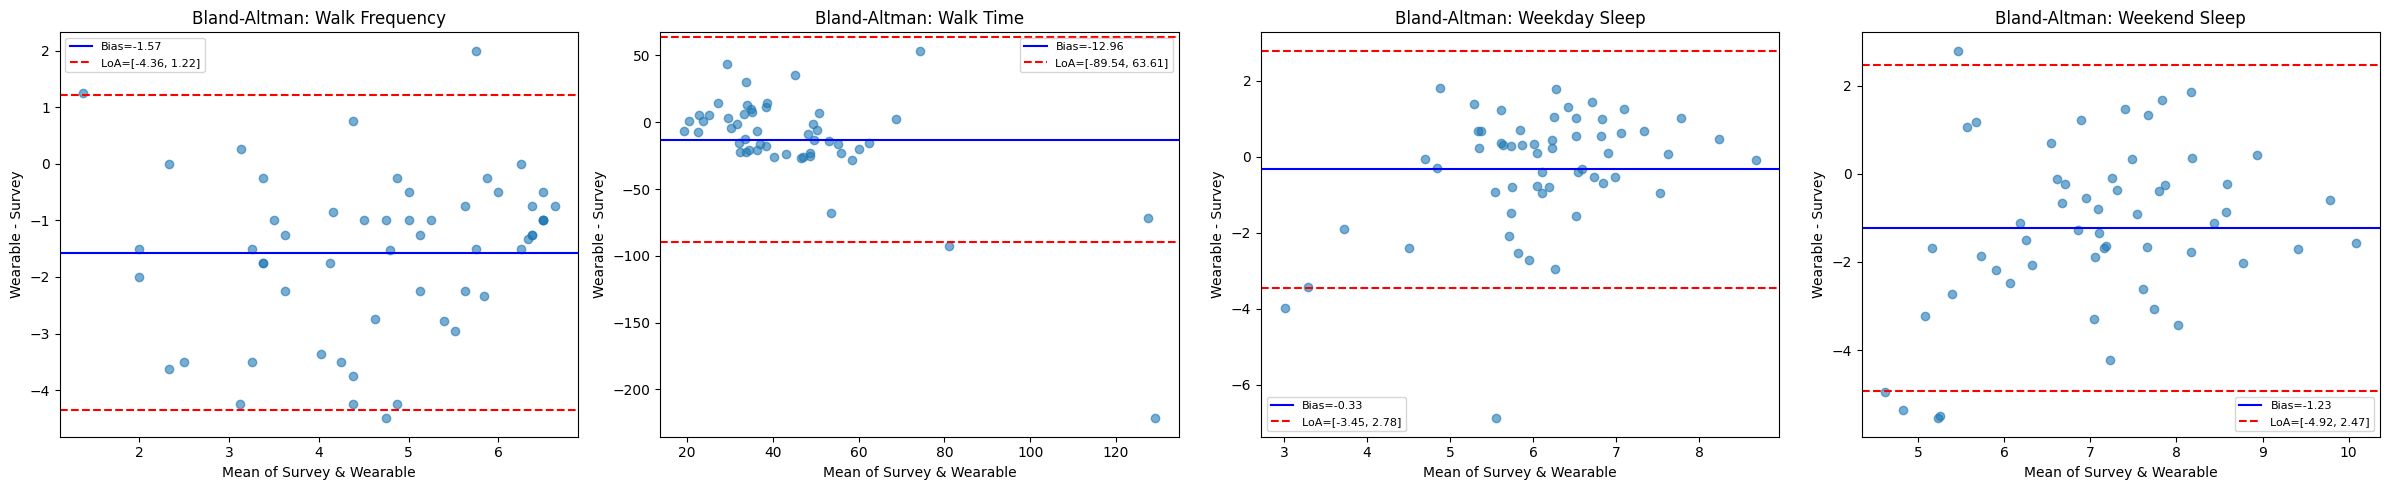

In [32]:
fig, axes = plt.subplots(1, len(same_unit_pairs), figsize=(6 * len(same_unit_pairs), 5))
if len(same_unit_pairs) == 1:
    axes = [axes]

for ax, (pair_name, pdf) in zip(axes, same_unit_pairs.items()):
    label = PAIR_LABELS.get(pair_name, pair_name)
    x = pdf['survey_value'].values
    y = pdf['wearable_value'].values
    mean_xy = (x + y) / 2
    diff = y - x
    bias = diff.mean()
    sd_diff = diff.std(ddof=1)
    loa_lo, loa_hi = bias - 1.96 * sd_diff, bias + 1.96 * sd_diff

    ax.scatter(mean_xy, diff, alpha=0.6)
    ax.axhline(bias, color='blue', linestyle='-', label=f'Bias={bias:.2f}')
    ax.axhline(loa_hi, color='red', linestyle='--', label=f'LoA=[{loa_lo:.2f}, {loa_hi:.2f}]')
    ax.axhline(loa_lo, color='red', linestyle='--')
    ax.set_xlabel('Mean of Survey & Wearable')
    ax.set_ylabel('Wearable - Survey')
    ax.set_title(f'Bland-Altman: {label}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/all_pairs_step4_bland_altman.png', dpi=150)
plt.show()

## Step 4. 관련성 분석 (Spearman + FDR 보정)
"두 지표가 같은 방향을 말하는가?"를 봄 — 절대값 일치가 아니라 순위 관계. 6개 지표 전체에 FDR(Benjamini-Hochberg) 보정을 적용.

In [33]:
from statsmodels.stats.multitest import multipletests

spearman_rows = []
for pair_name, pdf in person_datasets.items():
    rho, p = sps.spearmanr(pdf['survey_value'], pdf['wearable_value'])
    spearman_rows.append({'pair': pair_name, 'n': len(pdf), 'rho': rho, 'p': p})

spearman_table = pd.DataFrame(spearman_rows)
reject, p_fdr, _, _ = multipletests(spearman_table['p'], method='fdr_bh')
spearman_table['p_fdr'] = p_fdr
spearman_table['significant_fdr'] = reject
spearman_table = spearman_table.round(4)
spearman_table

,pair,n,rho,p,p_fdr,significant_fdr
0,수면질,57,0.1842,0.1702,0.2042,False
1,야간각성①,57,0.0308,0.8200,0.8200,False
2,걷기빈도,55,0.5850,0.0000,0.0000,True
3,걷기시간,51,0.2547,0.0713,0.1070,False
4,주중_수면시간,56,0.3428,0.0097,0.0291,True
5,주말_수면시간,54,0.3112,0.0220,0.0440,True


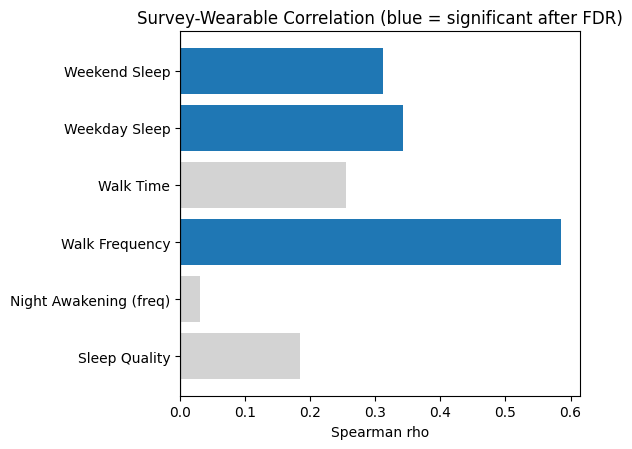

In [34]:
fig, ax = plt.subplots(figsize=(6, 0.6 * len(spearman_table) + 1))
labels = [PAIR_LABELS.get(p, p) for p in spearman_table['pair']]
colors = ['tab:blue' if sig else 'lightgray' for sig in spearman_table['significant_fdr']]
ax.barh(labels, spearman_table['rho'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman rho')
ax.set_title('Survey-Wearable Correlation (blue = significant after FDR)')
plt.tight_layout()
plt.savefig('results/all_pairs_step5_spearman.png', dpi=150)
plt.show()

## Step 5. 반복측정 관계 분석 (혼합효과모형)
person×week 데이터(`df_merged`)는 한 사람이 최대 4번 반복 측정된 것이라 관측치 간 독립이 아님 — Kruskal-Wallis 대신 **혼합효과모형**(웨어러블 = 설문값 + 주차 + 개인 random intercept) 사용. Boxplot은 시각화 목적으로만 병행.

In [35]:
# 걷기빈도/걷기시간은 PAIRS의 require_main_analysis_flag를 반영해 ICC/Spearman과 동일한 필터를 적용한다
# (그렇지 않으면 표시된 n(55/51)보다 큰 표본으로 계산되는 불일치가 생긴다).
import statsmodels.formula.api as smf

mixed_rows = []
mixed_fits = {}
for pair_name, spec in PAIRS.items():
    survey_col, wearable_col = spec['survey_col'], spec['wearable_col']
    src_df = df_merged[df_merged['main_analysis_flag'] == True] if spec.get('require_main_analysis_flag') else df_merged
    df_pw = src_df[['id', 'week', survey_col, wearable_col]].dropna().copy()
    df_pw.columns = ['id', 'week', 'survey', 'wearable']
    if spec.get('require_main_analysis_flag'):
        n_weeks_per_id = df_pw.groupby('id').size()
        valid_ids = n_weeks_per_id[n_weeks_per_id >= MIN_WEEKS_PERSON].index
        df_pw = df_pw[df_pw['id'].isin(valid_ids)].copy()
    df_pw['week'] = df_pw['week'].astype(str)

    fit = smf.mixedlm("wearable ~ survey + week", df_pw, groups=df_pw['id']).fit()
    mixed_fits[pair_name] = fit

    coef = fit.params['survey']
    ci_lo, ci_hi = fit.conf_int().loc['survey']
    mixed_rows.append({
        'pair': pair_name, 'n_obs': len(df_pw), 'n_id': df_pw['id'].nunique(),
        'survey_coef': round(coef, 3), 'se': round(fit.bse['survey'], 3),
        'p': round(fit.pvalues['survey'], 4),
        'p_raw_precise': fit.pvalues['survey'],
        'CI': f'[{ci_lo:.3f}, {ci_hi:.3f}]',
    })

mixed_table = pd.DataFrame(mixed_rows)
mixed_table

,pair,n_obs,n_id,survey_coef,se,p,p_raw_precise,CI
0,수면질,214,57,1.318,0.923,0.1530,1.529783e-01,"[-0.490, 3.127]"
1,야간각성①,213,57,-0.749,0.900,0.4052,4.051860e-01,"[-2.513, 1.015]"
2,걷기빈도,216,55,0.388,0.076,0.0000,3.733153e-07,"[0.239, 0.538]"
3,걷기시간,194,51,0.102,0.051,0.0464,4.637235e-02,"[0.002, 0.203]"
4,주중_수면시간,209,56,0.337,0.109,0.0020,2.009481e-03,"[0.123, 0.552]"
5,주말_수면시간,187,54,0.261,0.110,0.0179,1.787181e-02,"[0.045, 0.477]"


In [36]:
# 반복측정 베타에도 Spearman과 동일한 6개 지표 패밀리로 BH-FDR을 적용한다.
from statsmodels.stats.multitest import multipletests

reject_mixed, p_fdr_mixed, _, _ = multipletests(mixed_table['p_raw_precise'], method='fdr_bh')
mixed_table['p_fdr'] = p_fdr_mixed
mixed_table['significant_fdr'] = reject_mixed
mixed_table

,pair,n_obs,n_id,survey_coef,se,p,p_raw_precise,CI,p_fdr,significant_fdr
0,수면질,214,57,1.318,0.923,0.1530,1.529783e-01,"[-0.490, 3.127]",0.183574,False
1,야간각성①,213,57,-0.749,0.900,0.4052,4.051860e-01,"[-2.513, 1.015]",0.405186,False
2,걷기빈도,216,55,0.388,0.076,0.0000,3.733153e-07,"[0.239, 0.538]",0.000002,True
3,걷기시간,194,51,0.102,0.051,0.0464,4.637235e-02,"[0.002, 0.203]",0.069559,False
4,주중_수면시간,209,56,0.337,0.109,0.0020,2.009481e-03,"[0.123, 0.552]",0.006028,True
5,주말_수면시간,187,54,0.261,0.110,0.0179,1.787181e-02,"[0.045, 0.477]",0.035744,True


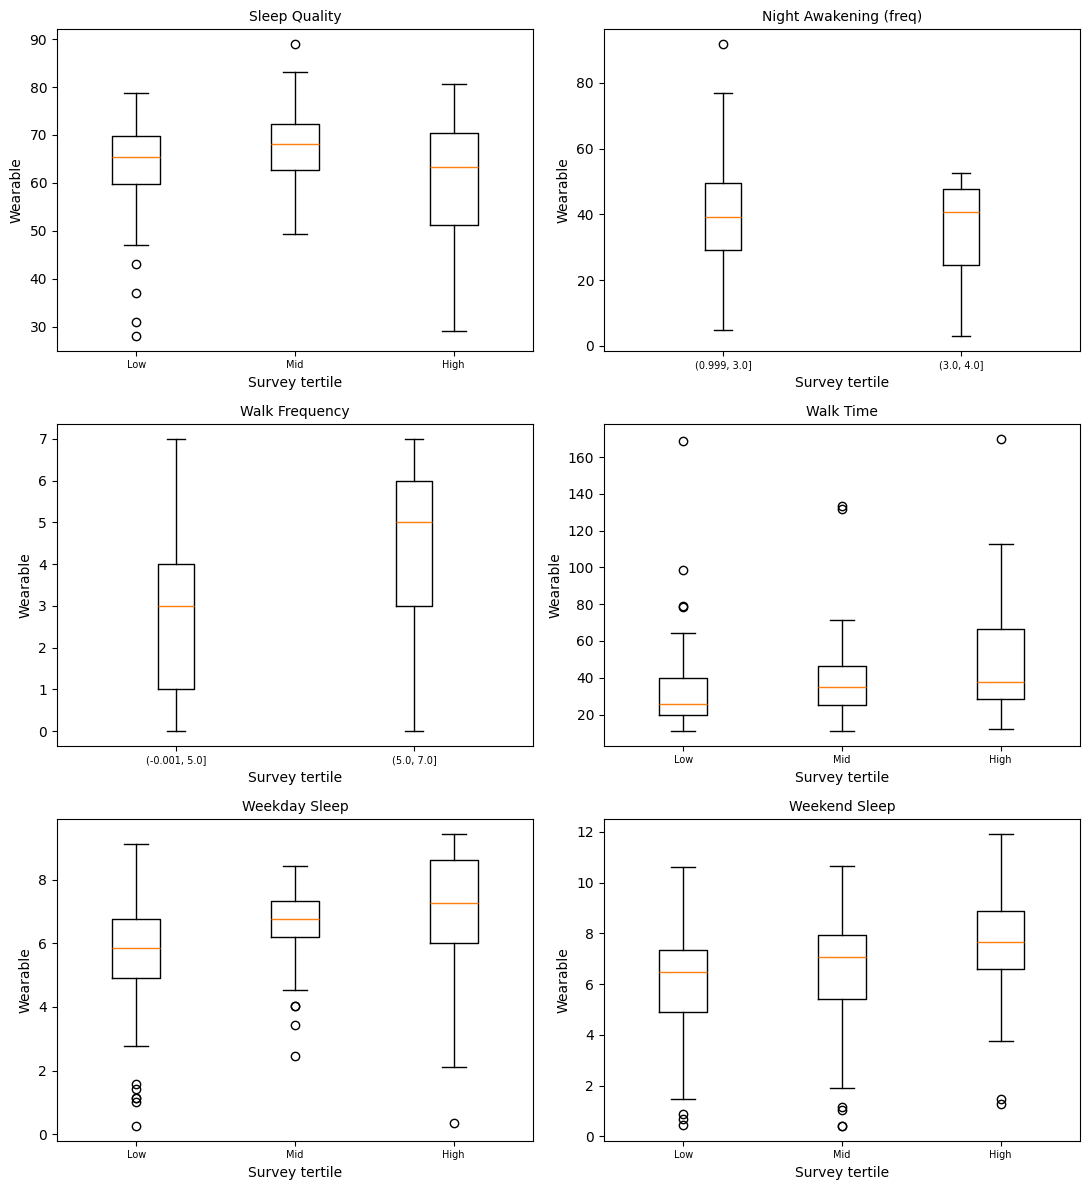

In [37]:
n_pairs = len(PAIRS)
n_cols = 2
n_rows = -(-n_pairs // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 4 * n_rows))
axes = axes.flatten()

for ax, (pair_name, spec) in zip(axes, PAIRS.items()):
    label = PAIR_LABELS.get(pair_name, pair_name)
    survey_col, wearable_col = spec['survey_col'], spec['wearable_col']
    df_pw = df_merged[[survey_col, wearable_col]].dropna().copy()
    df_pw.columns = ['survey', 'wearable']
    try:
        df_pw['tertile'] = pd.qcut(df_pw['survey'], 3, labels=['Low', 'Mid', 'High'], duplicates='drop')
    except ValueError:
        # 값이 한쪽으로 쏠려 3분위가 안 나뉘는 경우 (예: 걷기빈도) -> 자동 구간 라벨로 대체
        df_pw['tertile'] = pd.qcut(df_pw['survey'], 3, duplicates='drop')

    groups = [g['wearable'].values for _, g in df_pw.groupby('tertile', observed=True)]
    ax.boxplot(groups, tick_labels=[str(c) for c in df_pw['tertile'].cat.categories])
    ax.set_xlabel('Survey tertile')
    ax.set_ylabel('Wearable')
    ax.set_title(f'{label}', fontsize=10)
    ax.tick_params(axis='x', labelsize=7)

for ax in axes[n_pairs:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('results/all_pairs_step6_boxplot.png', dpi=150)
plt.show()

### Step 2~5 종합 해석

순위상관(Spearman)과 반복측정 관계는 걷기빈도·주중/주말 수면시간에서 유의했으나, ICC는 네 지표 모두 0.50 미만으로 낮은 절대일치도를 보였다. **관련성이 존재한다고 해서 개인 수준의 절대일치도와 상호대체 가능성이 확보되는 것은 아니다** — 측정방법 간 관계의 강도와 절대일치도는 구분해서 해석해야 한다.

## D-3: within-person 시간효과 반영을 위한 person-week 재구성

D-1A는 참여자당 지표당 D_ij(4주 평균 1개 값)를 person-level SD_j(D)(전체기간 고정)로 표준화했다.
이 방식은 "평소 스트레스가 높은 사람이 간극도 큰가"(between-person)만 볼 수 있고,
"같은 사람이 자기 평소보다 스트레스가 높았던 주에 간극도 커지는가"(within-person)는 볼 수 없다.

이를 위해 D_ijt(참여자×지표×**주차**)를 주차 단위로 유지하고, 표준화 분모도 SD_j(D)(전체기간)
대신 **SD_jt(D)(그 주차만의 SD)**로 교체한다. 걷기 지표는 D-1A와 동일하게 main_analysis_flag를
적용하고, 수면시간은 D-1A와 동일하게 주중 10박·주말 4박 이상의 야간수면, 서로 다른 3주 이상, 설문 3회 이상 기준을 적용한다.

In [38]:
INDICATORS_T = {
    '걷기빈도': (WALK_FREQ_COL, 'walk_days_10min', True),
    '걷기시간': (WALK_TIME_COL, 'walk_time_10min', True),
    '주중_수면시간': (SLEEP_WD_COL, 'w_weekday_sleep_hr', False),
    '주말_수면시간': (SLEEP_WE_COL, 'w_weekend_sleep_hr', False),
}

# D-1A와 동일한 참여자 자격기준을 적용한다 — Table 2 스트레스-간극분석 열(55/51/46/43)과
# 정확히 같은 기준: 걷기는 main_analysis_flag 통과 주가 3주 이상인 사람,
# 수면시간은 build_sleep_person_level()의 main_weekday_flag/main_weekend_flag(야간수면
# 10박/4박 이상+3주 이상+설문 3회 이상)를 통과한 사람만 포함.
walk_freq_ids = set(build_person_D_walk(WALK_FREQ_COL, 'walk_days_10min')['id'])
walk_time_ids = set(build_person_D_walk(WALK_TIME_COL, 'walk_time_10min')['id'])
wd_sleep_ids = set(sleep_person[sleep_person['main_weekday_flag']]['id'])
we_sleep_ids = set(sleep_person[sleep_person['main_weekend_flag']]['id'])
ELIGIBLE_IDS_T = {
    '걷기빈도': walk_freq_ids, '걷기시간': walk_time_ids,
    '주중_수면시간': wd_sleep_ids, '주말_수면시간': we_sleep_ids,
}
print('지표별 자격 참여자 수(Table 2 스트레스-간극분석 열과 동일해야 함):',
      {k: len(v) for k, v in ELIGIBLE_IDS_T.items()})

rows_t = []
for name, (scol, wcol, require_flag) in INDICATORS_T.items():
    src = df_merged[df_merged['main_analysis_flag'] == True] if require_flag else df_merged
    src = src[src['id'].isin(ELIGIBLE_IDS_T[name])]
    d = src[['id', 'week', scol, wcol]].dropna(subset=[scol, wcol]).copy()
    d.columns = ['id', 'week', 'S', 'W']
    d['D'] = d['S'] - d['W']
    d['indicator'] = name
    rows_t.append(d)

d3_long = pd.concat(rows_t, ignore_index=True)

# 표준화 분모를 지표x주차별 SD_j(D)_t로 계산
d3_long['SD_jt'] = d3_long.groupby(['indicator', 'week'])['D'].transform('std')
d3_long['D_star_t'] = d3_long['D'] / d3_long['SD_jt']
d3_long['absD_star_t'] = d3_long['D_star_t'].abs()

print('\n지표x주차별 n / SD_j(D)_t:')
print(d3_long.groupby(['indicator', 'week'])['D'].agg(['size', 'std']))
print(f"\n전체 참여자x지표x주차 행수: {len(d3_long)}, 고유 참여자: {d3_long['id'].nunique()}명")
print(f"SD_jt 결측(계산 불가) 행: {d3_long['D_star_t'].isna().sum()}건")

d3_long.to_csv('results/d3_person_week_indicator.csv', index=False)
print('저장 완료: d3_person_week_indicator.csv')
d3_long.head(10)

지표별 자격 참여자 수(Table 2 스트레스-간극분석 열과 동일해야 함): {'걷기빈도': 55, '걷기시간': 51, '주중_수면시간': 46, '주말_수면시간': 43}

지표x주차별 n / SD_j(D)_t:
                size        std
indicator week                 
걷기빈도      1       51   2.143298
          2       55   2.005548
          3       55   1.980035
          4       55   1.854651
걷기시간      1       45  49.044666
          2       50  50.564037
          3       48  47.091010
          4       51  36.073800
주말_수면시간   1       38   1.853341
          2       43   2.874113
          3       41   2.349635
          4       41   2.329419
주중_수면시간   1       46   1.032612
          2       46   1.646503
          3       46   1.522057
          4       45   1.355312

전체 참여자x지표x주차 행수: 756, 고유 참여자: 56명
SD_jt 결측(계산 불가) 행: 0건
저장 완료: d3_person_week_indicator.csv


,id,week,S,W,D,indicator,SD_jt,D_star_t,absD_star_t
0,1,1,5.0,3.0,2.0,걷기빈도,2.143298,0.933141,0.933141
1,1,2,5.0,4.0,1.0,걷기빈도,2.005548,0.498617,0.498617
2,1,3,4.0,1.0,3.0,걷기빈도,1.980035,1.515125,1.515125
3,1,4,3.0,2.0,1.0,걷기빈도,1.854651,0.539185,0.539185
4,2,1,4.0,7.0,-3.0,걷기빈도,2.143298,-1.399712,1.399712
5,2,2,3.0,1.0,2.0,걷기빈도,2.005548,0.997234,0.997234
6,2,3,4.0,4.0,0.0,걷기빈도,1.980035,0.000000,0.000000
7,2,4,7.0,3.0,4.0,걷기빈도,1.854651,2.156740,2.156740
8,3,1,5.0,3.0,2.0,걷기빈도,2.143298,0.933141,0.933141
9,3,2,3.0,4.0,-1.0,걷기빈도,2.005548,-0.498617,0.498617


## D-3 2단계: within/between 스트레스 분해 + 주차 고정효과 + 크로스 임의효과

$$|D^*_{ijt}| = \beta_0 + \gamma_j Indicator_j + \beta_W Stress^{within}_{it} + \beta_B Stress_i + \beta_1 Gender_i + \beta_2 Coverage^{within}_{ijt} + \beta_3 Coverage_{ij} + \delta_t + u_i + v_{ij} + \epsilon_{ijt}$$

스트레스와 기록충실도(coverage)를 각각 참여자 평균(between)과 그 주의 편차(within)로 분해하고,
주차 고정효과($\delta_t$)와 참여자×지표 임의절편($v_{ij}$, `vc_formula`)을 추가한다.

In [39]:
d3 = d3_long.copy()

# 주중/주말 수면시간의 coverage_ratio는 D-1A(build_sleep_person_level)와 같은 개념인
# '해당 주 윈도우 내 평일/주말 야간수면 실측 비율'로 계산한다(걷기와는 다른 정의).
# night_ratio_weekday/weekend는 data/wearable_person_week.csv에 사전계산되어 포함되어 있다.
cov_map = df_merged[['id', 'week', 'pedometer_record_days', 'match_quality',
                      'night_ratio_weekday', 'night_ratio_weekend']].drop_duplicates(subset=['id', 'week'])
d3 = d3.merge(cov_map, on=['id', 'week'], how='left')

def _coverage_row(r):
    if r['indicator'] in ['걷기빈도', '걷기시간']:
        return r['pedometer_record_days'] / 7
    elif r['indicator'] == '주중_수면시간':
        return r['night_ratio_weekday']
    else:
        return r['night_ratio_weekend']

d3['coverage_ratio'] = d3.apply(_coverage_row, axis=1)

# 스트레스: person-week 유니크 기준으로 between/within 분해
# (d3_long은 지표별로 중복된 long-format이라, 그대로 groupby('id')하면 지표 수만큼 가중치가 왜곡됨 -> 먼저 유니크 (id,week)에서 계산 후 병합)
stress_pw = df_merged[['id', 'week', 'stress']].drop_duplicates(subset=['id', 'week']).copy()
stress_pw['stress_between'] = stress_pw.groupby('id')['stress'].transform('mean')
stress_pw['stress_within'] = stress_pw['stress'] - stress_pw['stress_between']
d3 = d3.merge(stress_pw[['id', 'week', 'stress_between', 'stress_within']], on=['id', 'week'], how='left')

# 커버리지도 within/between 분해 (지표별로 정의가 달라 groupby(['id','indicator'])로 분리)
d3['coverage_between'] = d3.groupby(['id', 'indicator'])['coverage_ratio'].transform('mean')
d3['coverage_within'] = d3['coverage_ratio'] - d3['coverage_between']

d3['gender'] = d3['id'].map(gender_by_id)

d3m = d3.dropna(subset=['absD_star_t', 'stress_between', 'stress_within', 'coverage_between', 'coverage_within', 'gender']).copy()
d3m['gender'] = d3m['gender'].astype(int).astype('category')
d3m['week'] = d3m['week'].astype(str)
d3m['id_indicator'] = d3m['id'].astype(str) + '_' + d3m['indicator']

print(f"모형 표본: {len(d3m)}행, {d3m['id'].nunique()}명")

formula_d3a = 'absD_star_t ~ C(indicator) + stress_within + stress_between + C(gender) + coverage_within + coverage_between + C(week)'
model_d3a = smf.mixedlm(formula_d3a, d3m, groups=d3m['id'], vc_formula={'id_indicator': '0 + C(id_indicator)'})
fit_d3a = model_d3a.fit(reml=True)
print(fit_d3a.summary())

d3m.to_csv('results/d3_d1a_model_data.csv', index=False)

모형 표본: 748행, 55명
              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    absD_star_t
No. Observations:    748        Method:                REML       
No. Groups:          55         Scale:                 0.3711     
Min. group size:     4          Log-Likelihood:        -808.6464  
Max. group size:     16         Converged:             Yes        
Mean group size:     13.6                                         
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                1.787    0.465  3.842 0.000  0.876  2.699
C(indicator)[T.걷기시간]    -0.374    0.105 -3.556 0.000 -0.581 -0.168
C(indicator)[T.주말_수면시간] -0.378    0.121 -3.132 0.002 -0.614 -0.141
C(indicator)[T.주중_수면시간] -0.470    0.130 -3.619 0.000 -0.725 -0.216
C(gender)[T.2]           0.103    0.079  1.309 0.191 -0.051 

## D-3 2-2단계: D-1B(수면의 질) within/between 분해

D-1B는 지표가 1개(수면의 질)뿐이라 지표 고정효과·참여자×지표 임의절편이 불필요하다.
$Z$표준화는 그 주(week) 횡단면 기준으로 계산해 $R_{ijt}=Z_t(S_{ijt})-Z_t(W_{ijt})$를 구성한다.

In [40]:
# D-1B(build_person_SW)와 동일한 참여자 자격기준(설문 응답 3회 이상, n_weeks>=3)을 적용한다.
# Table 2 스트레스-간극분석 열(수면의 질=53명)과 일치하는지 확인.
sleepq_eligible_ids = set(build_person_SW(SLEEP_QUALITY_COL, 'w_sleep_score')['id'])
print('수면의 질 자격 참여자 수(Table 2와 동일해야 함):', len(sleepq_eligible_ids))

d1b_t = df_merged[['id', 'week', SLEEP_QUALITY_COL, 'w_sleep_score', 'match_quality']].dropna(
    subset=[SLEEP_QUALITY_COL, 'w_sleep_score']).copy()
d1b_t.columns = ['id', 'week', 'S', 'W', 'match_quality']
d1b_t = d1b_t[d1b_t['id'].isin(sleepq_eligible_ids)]

# 그 주(week) 횡단면 기준 Z표준화
d1b_t['Zs_t'] = d1b_t.groupby('week')['S'].transform(lambda x: (x - x.mean()) / x.std())
d1b_t['Zw_t'] = d1b_t.groupby('week')['W'].transform(lambda x: (x - x.mean()) / x.std())
d1b_t['R_t'] = d1b_t['Zs_t'] - d1b_t['Zw_t']
d1b_t['absR_t'] = d1b_t['R_t'].abs()

d1b_t['coverage_ratio'] = d1b_t['match_quality'] / 7
d1b_t['coverage_between'] = d1b_t.groupby('id')['coverage_ratio'].transform('mean')
d1b_t['coverage_within'] = d1b_t['coverage_ratio'] - d1b_t['coverage_between']

d1b_t = d1b_t.merge(stress_pw[['id', 'week', 'stress_between', 'stress_within']], on=['id', 'week'], how='left')
d1b_t['gender'] = d1b_t['id'].map(gender_by_id)

d1b_tm = d1b_t.dropna(subset=['R_t', 'stress_between', 'stress_within', 'coverage_between', 'coverage_within', 'gender']).copy()
d1b_tm['gender'] = d1b_tm['gender'].astype(int).astype('category')
d1b_tm['week'] = d1b_tm['week'].astype(str)

print(f"D-1B 모형 표본: {len(d1b_tm)}행, {d1b_tm['id'].nunique()}명")

formula_d3b = 'R_t ~ stress_within + stress_between + C(gender) + coverage_within + coverage_between + C(week)'
fit_d3b_R = smf.mixedlm(formula_d3b, d1b_tm, groups=d1b_tm['id']).fit(reml=True)
print('--- R_t (방향) ---')
print(fit_d3b_R.summary())

fit_d3b_absR = smf.mixedlm(formula_d3b.replace('R_t', 'absR_t'), d1b_tm, groups=d1b_tm['id']).fit(reml=True)
print('--- absR_t (크기) ---')
print(fit_d3b_absR.summary())

d1b_tm.to_csv('results/d3_d1b_model_data.csv', index=False)

수면의 질 자격 참여자 수(Table 2와 동일해야 함): 53
D-1B 모형 표본: 205행, 52명
--- R_t (방향) ---
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  R_t      
No. Observations:   205      Method:              REML     
No. Groups:         52       Scale:               0.7313   
Min. group size:    3        Log-Likelihood:      -296.9919
Max. group size:    4        Converged:           Yes      
Mean group size:    3.9                                    
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         2.264    0.683  3.316 0.001  0.926  3.603
C(gender)[T.2]    0.215    0.253  0.850 0.395 -0.281  0.712
C(week)[T.2]      0.112    0.173  0.650 0.515 -0.226  0.451
C(week)[T.3]      0.037    0.170  0.221 0.825 -0.295  0.370
C(week)[T.4]      0.045    0.171  0.265 0.791 -0.289  0.380
stress_within    -0.319    0.161 -1.

## D-3 3단계: 참여자단위 부트스트랩 강건성 확인

삼성헬스 D-1과 동일하게 성공률<50%면 cluster-robust로 대체하는 절차를 적용한다.

In [41]:
def boot_d3(data, formula, groups_col, target_terms, vc_formula=None, n_target=300, max_attempts=500, seed=1):
    ids = data[groups_col].unique()
    rng = np.random.default_rng(seed)
    results = {t: [] for t in target_terms}
    attempts = 0
    while len(results[target_terms[0]]) < n_target and attempts < max_attempts:
        attempts += 1
        samp_ids = rng.choice(ids, size=len(ids), replace=True)
        parts = []
        for i, sid in enumerate(samp_ids):
            sub = data[data[groups_col] == sid].copy()
            sub['_bid'] = f'{sid}_{i}'
            if vc_formula is not None:
                sub['_id_ind'] = sub['_bid'] + '_' + sub['indicator']
            parts.append(sub)
        dboot = pd.concat(parts, ignore_index=True)
        try:
            if vc_formula is not None:
                fit = smf.mixedlm(formula, dboot, groups=dboot['_bid'], vc_formula={'id_indicator': '0 + C(_id_ind)'}).fit(reml=True)
            else:
                fit = smf.mixedlm(formula, dboot, groups=dboot['_bid']).fit(reml=True)
            for t in target_terms:
                results[t].append(fit.params[t])
        except Exception:
            continue
    success_rate = len(results[target_terms[0]]) / attempts if attempts > 0 else 0
    print(f'  시도{attempts}회, 성공{len(results[target_terms[0]])}회 (성공률 {success_rate*100:.1f}%)')
    if success_rate < 0.5:
        print('  성공률<50% -> 참여자 군집강건(OLS cluster-robust)으로 대체 필요')
        return None
    for t in target_terms:
        print(f'  {t} 95%CI:', np.percentile(results[t], [2.5, 97.5]))
    return results

print('=== D-1A(간극 크기, 4지표 풀링) 부트스트랩 ===')
_ = boot_d3(d3m, formula_d3a, 'id', ['stress_within', 'stress_between'], vc_formula=True)

print('\n=== D-1B(수면의 질, R_t) 부트스트랩 ===')
_ = boot_d3(d1b_tm, formula_d3b, 'id', ['stress_within', 'stress_between'])

=== D-1A(간극 크기, 4지표 풀링) 부트스트랩 ===
  시도300회, 성공300회 (성공률 100.0%)
  stress_within 95%CI: [-0.14556436  0.04103184]
  stress_between 95%CI: [0.04908313 0.39768487]

=== D-1B(수면의 질, R_t) 부트스트랩 ===
  시도300회, 성공300회 (성공률 100.0%)
  stress_within 95%CI: [-6.65500524e-01 -1.27007150e-04]
  stress_between 95%CI: [-1.08315131 -0.29591876]


## D-3 4단계: 수면시간 단일지표(주중+주말) within/between 분해 (Fitbit 수면시간 모형과의 방향 비교용)

Fitbit은 수면시간 단일지표만 비교 가능하므로, 삼성헬스도 걷기 지표를 제외하고 수면시간 2지표(주중+주말)만으로 D-3 2단계와 동일한 within/between 모형을 적합한다. 모형·공변량·부트스트랩 절차(성공률<50%면 cluster-robust 대체)는 D-3 2·3단계와 같고, 주중·주말 단독 모형도 함께 제시한다. P값은 혼합모형의 모형 기반 값이고 95% CI는 참여자단위 부트스트랩 백분위수이다.

In [42]:
sleep_sets = {
    '수면시간 2지표(주중+주말)': (d3m[d3m['indicator'].isin(['주중_수면시간', '주말_수면시간'])].copy(), formula_d3a, True),
    '주중 수면시간': (d3m[d3m['indicator'] == '주중_수면시간'].copy(), formula_d3a.replace('C(indicator) + ', ''), False),
    '주말 수면시간': (d3m[d3m['indicator'] == '주말_수면시간'].copy(), formula_d3a.replace('C(indicator) + ', ''), False),
}

rows_sleep = []
for label, (sub, formula, pooled) in sleep_sets.items():
    if pooled:
        fit = smf.mixedlm(formula, sub, groups=sub['id'], vc_formula={'id_indicator': '0 + C(id_indicator)'}).fit(reml=True)
    else:
        fit = smf.mixedlm(formula, sub, groups=sub['id']).fit(reml=True)
    print(f"\n=== {label}: {len(sub)}행, {sub['id'].nunique()}명 ===")
    boot = boot_d3(sub, formula, 'id', ['stress_within', 'stress_between'], vc_formula=True if pooled else None)
    for term in ['stress_within', 'stress_between']:
        model_ci = fit.conf_int().loc[term]
        if boot is not None:
            boot_lo, boot_hi = np.percentile(boot[term], [2.5, 97.5])
        else:
            boot_lo, boot_hi = np.nan, np.nan
        rows_sleep.append({'표본': label, '항': term.replace('stress_', ''), 'n_obs': len(sub), 'n_id': sub['id'].nunique(),
                           'coef': fit.params[term], '모형기반 P': fit.pvalues[term],
                           '모형기반 CI_lo': model_ci[0], '모형기반 CI_hi': model_ci[1],
                           '부트스트랩 CI_lo': boot_lo, '부트스트랩 CI_hi': boot_hi})

print("\n[삼성헬스 수면시간 within/between 요약]")
print(pd.DataFrame(rows_sleep).round(3).to_string(index=False))



=== 수면시간 2지표(주중+주말): 346행, 47명 ===
  시도300회, 성공300회 (성공률 100.0%)
  stress_within 95%CI: [-0.25804622  0.12565088]
  stress_between 95%CI: [0.00408826 0.32395197]

=== 주중 수면시간: 183행, 46명 ===


  시도300회, 성공300회 (성공률 100.0%)
  stress_within 95%CI: [-0.2538241   0.18057185]
  stress_between 95%CI: [-0.02909646  0.31285107]

=== 주말 수면시간: 163행, 43명 ===


  시도300회, 성공300회 (성공률 100.0%)
  stress_within 95%CI: [-0.39417349  0.17270472]
  stress_between 95%CI: [-0.00914976  0.3886586 ]

[삼성헬스 수면시간 within/between 요약]
             표본       항  n_obs  n_id   coef  모형기반 P  모형기반 CI_lo  모형기반 CI_hi  부트스트랩 CI_lo  부트스트랩 CI_hi
수면시간 2지표(주중+주말)  within    346    47 -0.058   0.521      -0.233       0.118       -0.258        0.126
수면시간 2지표(주중+주말) between    346    47  0.161   0.017       0.029       0.294        0.004        0.324
        주중 수면시간  within    183    46 -0.039   0.755      -0.283       0.205       -0.254        0.181
        주중 수면시간 between    183    46  0.140   0.116      -0.034       0.314       -0.029        0.313
        주말 수면시간  within    163    43 -0.096   0.470      -0.355       0.164       -0.394        0.173
        주말 수면시간 between    163    43  0.184   0.084      -0.025       0.392       -0.009        0.389


### D-3 종합 해석

D-1A(불일치 크기)에서는 between-person 관계만 유의(참여자 간 평소 스트레스 차이)했고 within-person은 비유의했다. 반면 D-1B(수면질 방향성 간극)에서는 within-person 관계도 유의했으나 부트스트랩 95% CI 상한이 0에 근접해 경계적이었다(βW=−0.319, P=.047) — 같은 사람이 평소보다 스트레스가 높은 주에는 자기보고 수면질이 웨어러블보다 상대적으로 더 낮게 보고되는 경향이 있었다. 즉 수면질 방향성 간극은 개인차(trait)뿐 아니라 개인 내 시간적 변동(state)에서도 스트레스와 연관된다.

수면시간 2지표(주중+주말)만으로 같은 모형을 적합하면 between-person 관계는 유의(βB=0.161, P=.017)했으나 within-person 관계는 비유의(βW=−0.058, P=.521)했다(D-3 4단계).

## Table 13: 시간분리 분석 및 예측 검증 (3.3절)

1-2주차의 초기 스트레스(`stress_early`)가 3-4주차의 후기 간극(`gap_late`)을 예측하는지 평가한다. 후기 간극은 D-1A의 네 지표(걷기빈도·걷기시간·주중수면·주말수면)에 대한 표준화 절대간극 `|D*|`의 평균으로 정의하며, 표준화 상수(정본 SD)는 D-1A와 동일하게 전체 4주 기준으로 산출한다.

모형: `Gap_후기 ~ Stress_초기 + Coverage_후기 + Gap_초기` (OLS, HC3 강건표준오차)

강건성은 leave-one-participant-out(LOPO) 교차검증(stress_early 포함 여부에 따른 예측오차 비교)과 참여자 단위 순열검정(2,000회)으로 확인한다.

In [43]:
WD_SLEEP_COL = "하루에 보통 몇 시간 주무십니까?_주중(또는 일하는 날)  ___시간"
WE_SLEEP_COL = "하루에 보통 몇 시간 주무십니까?_주말(또는 일하지 않는 날, 일하지 않는 전날)  ___시간"
WALK_FREQ_COL = "지난 일주일 동안 한번에 적어도 10분 이상 걷는 날은 며칠입니까?※ 출퇴근 또는 등하교, 이동 및 운동을 위해 걷는 것을 모두 포함하여 대답해 주십시오."
WALK_TIME_COL = "지난 일주일 동안 한번에 적어도 10분 이상 걸은 날 중 하루 동안 걷는 시간은 보통 얼마나 됩니까?하루에 _시간 _분※ 첫번째 행에는 시간    두번째 행에는 분_총_분"

INDICATORS = [
    ('걷기빈도', WALK_FREQ_COL, 'walk_days_10min'),
    ('걷기시간', WALK_TIME_COL, 'walk_time_10min'),
    ('주중수면', WD_SLEEP_COL, 'w_weekday_sleep_hr'),
    ('주말수면', WE_SLEEP_COL, 'w_weekend_sleep_hr'),
]

# ---------- 1) 정본 SD(D) 산출 (전체 4주 기준, D-1A와 동일한 표준화 상수) ----------
def canonical_sd(scol, wcol, weight_col='match_quality'):
    d = df_merged[['id', scol, wcol, weight_col]].dropna(subset=[scol, wcol]).copy()
    def wm(g):
        w = g[weight_col]
        if w.sum() <= 0:
            return pd.Series({'S': np.nan, 'W': np.nan})
        return pd.Series({'S': (g[scol]*w).sum()/w.sum(), 'W': (g[wcol]*w).sum()/w.sum()})
    g = d.groupby('id').apply(wm, include_groups=False).dropna()
    D = g['S'] - g['W']
    return D.std()

sd_by_indicator = {name: canonical_sd(scol, wcol) for name, scol, wcol in INDICATORS}
print("정본 SD(D) (전체 4주 기준):", {k: round(v, 3) for k, v in sd_by_indicator.items()})

# ---------- 2) 기간별(초기 1-2주 / 후기 3-4주) 개인 수준 |D*| 산출 ----------
def period_absDstar(scol, wcol, weight_col='match_quality'):
    early = df_merged[df_merged['week'].isin([1, 2])]
    late = df_merged[df_merged['week'].isin([3, 4])]
    out = {}
    for label, sub in [('early', early), ('late', late)]:
        d = sub[['id', scol, wcol, weight_col]].dropna(subset=[scol, wcol]).copy()
        def wm(g):
            w = g[weight_col]
            if w.sum() <= 0:
                return pd.Series({'S': np.nan, 'W': np.nan})
            return pd.Series({'S': (g[scol]*w).sum()/w.sum(), 'W': (g[wcol]*w).sum()/w.sum()})
        g = d.groupby('id').apply(wm, include_groups=False).dropna()
        out[label] = g
    return out

per_indicator_period = {name: period_absDstar(scol, wcol) for name, scol, wcol in INDICATORS}

# 사람 x 기간 단일 Gap 점수: 이용 가능한 지표들의 |D*| 평균
def build_person_period_gap(period_key):
    rows = []
    for pid in df_merged['id'].unique():
        vals = []
        for name, scol, wcol in INDICATORS:
            g = per_indicator_period[name][period_key]
            if pid in g.index:
                D = g.loc[pid, 'S'] - g.loc[pid, 'W']
                vals.append(abs(D) / sd_by_indicator[name])
        if len(vals) > 0:
            rows.append({'id': pid, f'gap_{period_key}': np.mean(vals), f'n_ind_{period_key}': len(vals)})
    return pd.DataFrame(rows)

gap_early = build_person_period_gap('early')
gap_late = build_person_period_gap('late')

# ---------- 3) 초기 스트레스, 기간별 coverage ----------
stress_early = df_merged[df_merged['week'].isin([1, 2])].groupby('id')['stress'].mean().rename('stress_early')
cov_early = df_merged[df_merged['week'].isin([1, 2])].groupby('id')['match_quality'].mean().div(7).rename('coverage_early')
cov_late = df_merged[df_merged['week'].isin([3, 4])].groupby('id')['match_quality'].mean().div(7).rename('coverage_late')

frame = gap_late.merge(gap_early, on='id', how='inner') \
    .merge(stress_early, on='id', how='left') \
    .merge(cov_early, on='id', how='left') \
    .merge(cov_late, on='id', how='left') \
    .dropna(subset=['gap_late', 'gap_early', 'stress_early', 'coverage_late'])

print(f"\n최종 분석표본: n={len(frame)}명 (초기+후기 모두 최소 1개 지표 있는 사람)")

# ---------- 4) 주모형 ----------
print("\n" + "=" * 70)
print("Gap_후기 ~ Stress_초기 + Coverage_후기 + Gap_초기")
print("=" * 70)
model_full = smf.ols("gap_late ~ stress_early + coverage_late + gap_early", frame).fit(cov_type='HC3')
print(model_full.summary().tables[1])

model_base = smf.ols("gap_late ~ coverage_late + gap_early", frame).fit(cov_type='HC3')

# ---------- 5) Leave-one-out 교차검증: stress_early 추가가 예측력을 높이는지 ----------
def loo_predict(formula, data):
    preds = np.full(len(data), np.nan)
    for i, idx in enumerate(data.index):
        train = data.drop(idx)
        test = data.loc[[idx]]
        try:
            r = smf.ols(formula, train).fit()
            preds[i] = r.predict(test).values[0]
        except Exception:
            preds[i] = np.nan
    return preds

frame = frame.reset_index(drop=True)
pred_full = loo_predict("gap_late ~ stress_early + coverage_late + gap_early", frame)
pred_base = loo_predict("gap_late ~ coverage_late + gap_early", frame)

valid = ~np.isnan(pred_full) & ~np.isnan(pred_base)
actual = frame.loc[valid, 'gap_late'].values
mse_full = np.mean((actual - pred_full[valid]) ** 2)
mse_base = np.mean((actual - pred_base[valid]) ** 2)
corr_full = np.corrcoef(actual, pred_full[valid])[0, 1]
corr_base = np.corrcoef(actual, pred_base[valid])[0, 1]

print("\n" + "=" * 70)
print("Leave-one-person-out 교차검증 (stress_early 추가 여부 비교)")
print("=" * 70)
print(f"[Full: +stress_early] OOF MSE={mse_full:.4f}, corr(actual,pred)={corr_full:.4f}")
print(f"[Base: -stress_early] OOF MSE={mse_base:.4f}, corr(actual,pred)={corr_base:.4f}")
print(f"MSE 개선(음수=개선): {mse_full - mse_base:.4f}")

# ---------- 6) 순열검정: stress_early의 효과가 우연 수준인지 (참여자 단위, 2000회) ----------
np.random.seed(3)
n_perm = 2000
obs_coef = model_full.params['stress_early']
perm_coefs = []
for _ in range(n_perm):
    shuffled = frame.copy()
    shuffled['stress_early'] = np.random.permutation(shuffled['stress_early'].values)
    r = smf.ols("gap_late ~ stress_early + coverage_late + gap_early", shuffled).fit()
    perm_coefs.append(r.params['stress_early'])
perm_coefs = np.array(perm_coefs)
pctile = (perm_coefs < obs_coef).mean() * 100
perm_p = 2 * min(pctile, 100 - pctile) / 100
print(f"\n참여자 단위 순열검정({len(perm_coefs)}회): 실제 stress_early 계수={obs_coef:.4f}, "
      f"순열분포 내 위치={pctile:.1f}%ile, 양측 순열p={perm_p:.4f}")


정본 SD(D) (전체 4주 기준): {'걷기빈도': 1.526, '걷기시간': 37.832, '주중수면': 1.59, '주말수면': 1.885}

최종 분석표본: n=54명 (초기+후기 모두 최소 1개 지표 있는 사람)

Gap_후기 ~ Stress_초기 + Coverage_후기 + Gap_초기
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.6102      0.326      1.874      0.061      -0.028       1.248
stress_early      0.2595      0.086      3.009      0.003       0.091       0.429
coverage_late    -0.7530      0.405     -1.858      0.063      -1.547       0.041
gap_early         0.3723      0.100      3.719      0.000       0.176       0.569

Leave-one-person-out 교차검증 (stress_early 추가 여부 비교)
[Full: +stress_early] OOF MSE=0.1688, corr(actual,pred)=0.6182
[Base: -stress_early] OOF MSE=0.1945, corr(actual,pred)=0.5377
MSE 개선(음수=개선): -0.0257

참여자 단위 순열검정(2000회): 실제 stress_early 계수=0.2595, 순열분포 내 위치=99.9%ile, 양측 순열p=0.0020


**해석**: 초기 스트레스가 초기 간극·후기 커버리지를 보정한 후에도 후기 간극을 유의하게 예측했고(β=0.260, P=.003), LOPO 교차검증에서도 스트레스를 포함한 모형이 예측오차가 낮았다(Pperm=.002). 이는 초기 스트레스가 동시적 관련성을 넘어 후속 간극의 예측표지자로 기능할 가능성을 시사하지만, 관찰연구이므로 인과적 선행성을 의미하지는 않는다.

## Table 14: 주중 및 주말 수면시간 저위험군 분석 (3.3절)

수면시간의 고간극(자기보고-웨어러블 절대차 >= 60분)을 스트레스와 기록 충실도(coverage)로 예측할 수 있는지, 그리고 예측확률이 낮은 '저위험군'에서 실제로 두 측정방법이 상호대체 가능한지를 leave-one-participant-out(LOPO) 교차검증으로 평가한다. 이 분석은 id=6을 제외한 표본에 대해 수행한다.

- M0: 절편만(기저율), M1: coverage만, M2: coverage + 참여자 평균 스트레스(stress_between)
- fold별 훈련자료 내에서 목표일치율 80%를 만족하는 가장 큰 예측확률 임계값(tau)으로 저위험군을 정의하고, 검증자료에 적용한다.
- 저위험군의 평균편향은 참여자 단위 군집부트스트랩(3,000회)으로, 동등성검정(90% CI, ±60분 기준)은 참여자 단위 군집부트스트랩(2,000회)으로 평가한다.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import statsmodels.api as sm

df_a14 = df_merged[df_merged['id'] != 6].copy()

TARGET_TOL_RATE = 0.80
TOLERANCE_MIN = 60

def calibrate_threshold(probs, high_gap, target_tol=TARGET_TOL_RATE):
    """훈련자료 내에서 예측확률 임계값 tau를 찾음: prob<=tau인 주(week)들의
    '허용오차(<=60분) 내 비율' >= target_tol을 만족하는 가장 큰 tau (=가장 큰 저위험군)."""
    order = np.argsort(probs)
    probs_sorted = probs[order]
    hg_sorted = high_gap[order]
    n = len(probs_sorted)
    cum_hg = np.cumsum(hg_sorted)
    best_tau = None
    for k in range(1, n + 1):
        tol_rate = 1 - cum_hg[k - 1] / k
        if tol_rate >= target_tol:
            best_tau = probs_sorted[k - 1]
    if best_tau is None:
        return -np.inf
    return best_tau

def build_base(scol, wcol):
    d = df_a14[['id', 'week', scol, wcol, 'match_quality', 'stress']].dropna(subset=[scol, wcol]).copy()
    d['diff_min'] = (d[scol] - d[wcol]) * 60  # 자기보고-웨어러블, 분
    d['high_gap'] = (d['diff_min'].abs() >= TOLERANCE_MIN).astype(int)
    d['coverage'] = d['match_quality'] / 7
    d['stress_between'] = d.groupby('id')['stress'].transform('mean')
    return d.reset_index(drop=True)

def run_lopo(d, label):
    ids = d['id'].unique()
    oof = {m: np.full(len(d), np.nan) for m in ['M0', 'M1', 'M2']}
    oof_lowrisk = np.zeros(len(d), dtype=bool)
    oof_tau = np.full(len(d), np.nan)

    for test_id in ids:
        train_idx = d.index[d['id'] != test_id]
        test_idx = d.index[d['id'] == test_id]
        train, test = d.loc[train_idx], d.loc[test_idx]
        if train['high_gap'].nunique() < 2:
            continue

        base_rate = train['high_gap'].mean()
        oof['M0'][test_idx] = base_rate

        cm, cs = train['coverage'].mean(), train['coverage'].std()
        tr_cov = ((train['coverage'] - cm) / cs).values.reshape(-1, 1)
        te_cov = ((test['coverage'] - cm) / cs).values.reshape(-1, 1)
        try:
            m1 = LogisticRegression(max_iter=1000).fit(tr_cov, train['high_gap'])
            oof['M1'][test_idx] = m1.predict_proba(te_cov)[:, 1]
        except Exception:
            oof['M1'][test_idx] = base_rate

        sm_, ss_ = train['stress_between'].mean(), train['stress_between'].std()
        tr_X = np.column_stack([tr_cov.ravel(), ((train['stress_between'] - sm_) / ss_).values])
        te_X = np.column_stack([te_cov.ravel(), ((test['stress_between'] - sm_) / ss_).values])
        try:
            m2 = LogisticRegression(max_iter=1000).fit(tr_X, train['high_gap'])
            oof['M2'][test_idx] = m2.predict_proba(te_X)[:, 1]
            tr_pred = m2.predict_proba(tr_X)[:, 1]
            tau = calibrate_threshold(tr_pred, train['high_gap'].values)
            oof_tau[test_idx] = tau
            oof_lowrisk[test_idx] = oof['M2'][test_idx] <= tau
        except Exception:
            oof['M2'][test_idx] = base_rate

    for m in ['M0', 'M1', 'M2']:
        d[f'pred_{m}'] = oof[m]
    d['low_risk'] = oof_lowrisk
    d['tau'] = oof_tau

    print(f"===== {label}: n={len(d)}, n_id={d['id'].nunique()} =====")
    valid = d.dropna(subset=['pred_M0', 'pred_M1', 'pred_M2'])
    y = valid['high_gap'].values
    for m in ['M0', 'M1', 'M2']:
        p = valid[f'pred_{m}'].values
        p_clip = np.clip(p, 1e-6, 1 - 1e-6)
        try:
            auroc = roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan
        except Exception:
            auroc = np.nan
        prauc = average_precision_score(y, p) if len(np.unique(y)) > 1 else np.nan
        brier = brier_score_loss(y, p)
        logit_p = np.log(p_clip / (1 - p_clip))
        try:
            cal = sm.Logit(y, sm.add_constant(logit_p)).fit(disp=0)
            cal_int, cal_slope = cal.params
        except Exception:
            cal_int, cal_slope = np.nan, np.nan
        print(f"  [{m}] AUROC={auroc:.3f}, PR-AUC={prauc:.3f}, Brier={brier:.4f}, "
              f"calib(intercept={cal_int:.3f}, slope={cal_slope:.3f})")
    print()
    return valid

def cluster_bootstrap_bias(sub, n_boot=3000, seed=1):
    ids = sub['id'].unique()
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        samp_ids = rng.choice(ids, size=len(ids), replace=True)
        rows = pd.concat([sub[sub['id'] == i] for i in samp_ids], ignore_index=True)
        boots.append(rows['diff_min'].mean())
    return np.percentile(boots, [2.5, 97.5])

def repeated_measures_loa(sub):
    # Bland & Altman (2007) repeated-measures 근사: 개인 간 분산 + 개인 내 분산
    person_stats = sub.groupby('id')['diff_min'].agg(['mean', 'count'])
    grand_mean = sub['diff_min'].mean()
    between_var = np.average((person_stats['mean'] - grand_mean) ** 2, weights=person_stats['count'])
    within_var = sub.groupby('id')['diff_min'].transform(lambda x: (x - x.mean()) ** 2).mean()
    total_sd = np.sqrt(between_var + within_var)
    return grand_mean - 1.96 * total_sd, grand_mean + 1.96 * total_sd, total_sd

def report_lowrisk(valid, label):
    qs = [0, 5, 10, 20, 25, 30, 40, 50, 75, 100]
    pctiles = np.percentile(valid['pred_M2'], qs)
    dist_str = ", ".join(f"{q}%={v:.3f}" for q, v in zip(qs, pctiles))
    print(f"[{label}] M2 예측확률(OOF) 분포: {dist_str}")
    tau_med = valid['tau'].median()
    print(f"[{label}] fold별 캘리브레이션 임계값(tau) 중앙값={tau_med:.3f} "
          f"(범위 [{valid['tau'].min():.3f},{valid['tau'].max():.3f}])")
    low = valid[valid['low_risk']]
    print(f"--- {label} 저위험군(fold별 목표일치율 {int(TARGET_TOL_RATE*100)}% 캘리브레이션) ---")
    print(f"저위험 person-week: {len(low)}건, 참여자 {low['id'].nunique()}명")
    if len(low) < 5:
        print("표본 부족으로 일치도 분석 생략")
        return
    bias = low['diff_min'].mean()
    ci_lo, ci_hi = cluster_bootstrap_bias(low)
    mae = low['diff_min'].abs().mean()
    within_tol = (low['diff_min'].abs() <= TOLERANCE_MIN).mean() * 100
    loa_lo, loa_hi, total_sd = repeated_measures_loa(low)
    print(f"평균편향(자기보고-웨어러블)={bias:.2f}분, 95%CI(군집부트스트랩)=[{ci_lo:.2f},{ci_hi:.2f}]")
    print(f"MAE={mae:.2f}분, ±{TOLERANCE_MIN}분 이내 일치율={within_tol:.1f}%")
    print(f"반복측정 Bland-Altman LoA=[{loa_lo:.2f},{loa_hi:.2f}]분 (총 SD={total_sd:.2f})")
    ids_low = low['id'].unique()
    rng90 = np.random.default_rng(2)
    boot_means_90 = []
    for _ in range(2000):
        samp_ids = rng90.choice(ids_low, size=len(ids_low), replace=True)
        rows = pd.concat([low[low['id'] == i] for i in samp_ids], ignore_index=True)
        boot_means_90.append(rows['diff_min'].mean())
    ci90_lo, ci90_hi = np.percentile(boot_means_90, [5, 95])
    equiv = (ci90_lo > -TOLERANCE_MIN) and (ci90_hi < TOLERANCE_MIN)
    print(f"동등성검정(90%CI 기준, 참여자 군집부트스트랩): [{ci90_lo:.2f},{ci90_hi:.2f}] -> {'동등성 충족' if equiv else '동등성 불충족'}")
    print()

for label, scol, wcol in [('주중', WD_SLEEP_COL, 'w_weekday_sleep_hr'), ('주말', WE_SLEEP_COL, 'w_weekend_sleep_hr')]:
    d = build_base(scol, wcol)
    valid = run_lopo(d, label)
    report_lowrisk(valid, label)


===== 주중: n=209, n_id=56 =====
  [M0] AUROC=0.200, PR-AUC=0.349, Brier=0.2497, calib(intercept=-16.937, slope=-75.076)
  [M1] AUROC=0.547, PR-AUC=0.540, Brier=0.2372, calib(intercept=-0.032, slope=0.855)
  [M2] AUROC=0.625, PR-AUC=0.587, Brier=0.2349, calib(intercept=-0.040, slope=0.820)

[주중] M2 예측확률(OOF) 분포: 0%=0.211, 5%=0.265, 10%=0.289, 20%=0.317, 25%=0.329, 30%=0.348, 40%=0.398, 50%=0.421, 75%=0.539, 100%=0.796
[주중] fold별 캘리브레이션 임계값(tau) 중앙값=0.282 (범위 [0.262,0.307])
--- 주중 저위험군(fold별 목표일치율 80% 캘리브레이션) ---
저위험 person-week: 25건, 참여자 10명
평균편향(자기보고-웨어러블)=-9.60분, 95%CI(군집부트스트랩)=[-45.00,18.26]
MAE=43.58분, ±60분 이내 일치율=72.0%
반복측정 Bland-Altman LoA=[-127.41,108.21]분 (총 SD=60.11)
동등성검정(90%CI 기준, 참여자 군집부트스트랩): [-37.17,14.39] -> 동등성 충족

===== 주말: n=186, n_id=53 =====
  [M0] AUROC=0.141, PR-AUC=0.443, Brier=0.2456, calib(intercept=24.893, slope=-65.721)
  [M1] AUROC=0.494, PR-AUC=0.628, Brier=0.2405, calib(intercept=0.157, slope=0.571)
  [M2] AUROC=0.572, PR-AUC=0.669, Brier=0.2394, calib(inter

**해석**: 스트레스를 추가하면 AUROC가 개선되지만(주중 0.547→0.625), 80% 목표일치율로 캘리브레이션한 저위험군에서도 평균절대오차 43.6분·±60분 일치율 72%(목표 미달)로 개인별 오차범위가 여전히 넓다. 즉 스트레스 기반 예측정보의 개선이 개인 수준의 측정방법 상호대체 가능성으로 이어지지는 않는다.

## Figure 3: 스트레스-불일치 관계의 Specification Curve (3.3절)

표본(canon/high-coverage), 공변량(base/CESD 보정), 추론방법(mixedlm/참여자 군집강건 OLS), 이상치 처리(전체/|D*|<=3만), 지표범위(pooled/sleep/walk)를 조합한 48개 분석 사양 각각에서 `mean_stress`가 표준화 절대간극(|D*|)을 예측하는 계수를 산출하고, 계수 크기순으로 정렬하여 제시한다. 전체 curve가 우연 수준을 넘어서는지는 cluster-robust 사양(24개)만 대상으로 한 참여자 단위 순열검정(500회, mean_stress를 참여자 간에 재배정)으로 평가한다.

총 사양 수: 48 (48개 중 표본부족 등으로 탈락한 것 제외)

양의 방향 비율: 100.0%
양의 방향+p<0.05 비율: 45.8%
계수 범위: [0.0104, 0.5504]
중앙값 계수: 0.2259

참여자단위 순열검정 (mean_stress를 참여자 간에 재배정, cluster-robust 사양만 재실행)
관찰된 중앙값 계수(cluster 사양, n=24): 0.2222
순열분포 내 위치: 99.4%ile (양측 순열p=0.0120)
관찰된 양의방향 비율(cluster 사양): 100.0%
순열분포 내 위치: 91.2%ile (양측 순열p=0.1760)


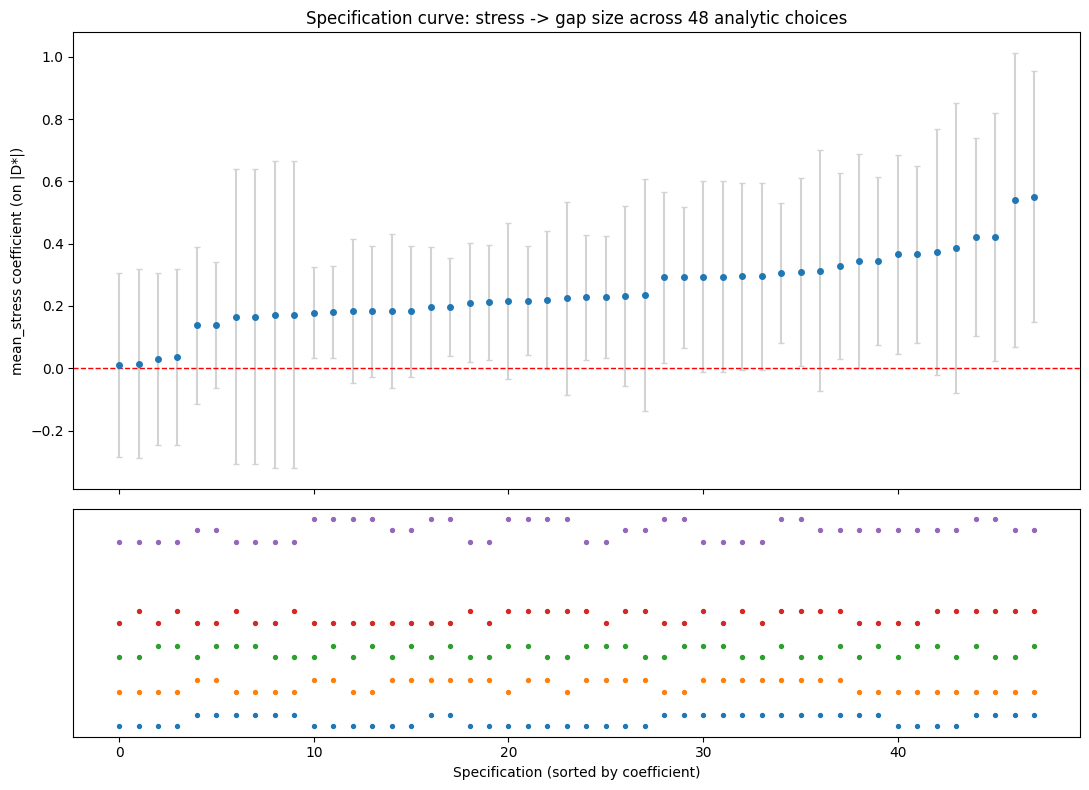


플롯 저장 완료: results/figure3_spec_curve.png


In [45]:
from itertools import product
import matplotlib.pyplot as plt

gender_by_id = df_merged[['id', 'gender']].dropna().drop_duplicates(subset=['id']).set_index('id')['gender']

INDICATORS_F3 = {
    '걷기빈도': (WALK_FREQ_COL, 'walk_days_10min', 'pedometer_record_days', 7, 'walk'),
    '걷기시간': (WALK_TIME_COL, 'walk_time_10min', 'pedometer_record_days', 7, 'walk'),
    '주중수면': (WD_SLEEP_COL, 'w_weekday_sleep_hr', 'match_quality', 7, 'sleep'),
    '주말수면': (WE_SLEEP_COL, 'w_weekend_sleep_hr', 'match_quality', 7, 'sleep'),
}
MIN_WEEKS_F3 = 3

def person_level_f3(scol, wcol, covcol, covdenom, min_weeks=MIN_WEEKS_F3):
    d = df_merged[['id', scol, wcol, covcol]].dropna(subset=[scol, wcol]).copy()
    def agg(g):
        w = g[covcol].clip(lower=0.01)
        return pd.Series({'S': (g[scol] * w).sum() / w.sum(), 'W': (g[wcol] * w).sum() / w.sum(),
                           'n_weeks': len(g), 'coverage_ratio': g[covcol].mean() / covdenom})
    g = d.groupby('id').apply(agg, include_groups=False)
    g = g[g['n_weeks'] >= min_weeks]
    return g.reset_index()

def build_frame_f3(mean_stress_by_id, mean_cesd_by_id, high_cov=False):
    frames = []
    for name, (scol, wcol, covcol, covdenom, dom) in INDICATORS_F3.items():
        g = person_level_f3(scol, wcol, covcol, covdenom)
        if high_cov:
            g = g[g['coverage_ratio'] >= 0.8]
        D = g['S'] - g['W']
        g['D_star'] = D / D.std()
        g['absD_star'] = g['D_star'].abs()
        g['indicator'] = name
        g['domain'] = dom
        g['gender'] = g['id'].map(gender_by_id)
        g['mean_stress'] = g['id'].map(mean_stress_by_id)
        g['mean_CESD'] = g['id'].map(mean_cesd_by_id)
        frames.append(g)
    return pd.concat(frames, ignore_index=True)

def run_spec_f3(frame, covset, infer, outlier, scope):
    d = frame.copy()
    if scope != 'pooled':
        d = d[d['domain'] == scope]
    need = ['absD_star', 'gender', 'coverage_ratio', 'mean_stress'] + (['mean_CESD'] if covset == 'cesd' else [])
    d = d.dropna(subset=need).copy()
    if outlier == 'exclude':
        d = d[d['absD_star'] <= 3]
    if len(d) < 15 or d['id'].nunique() < 5:
        return None
    d['gender'] = d['gender'].astype(int).astype('category')
    multi_ind = d['indicator'].nunique() > 1
    rhs = ("C(indicator) + " if multi_ind else "") + "C(gender) + coverage_ratio"
    if covset == 'cesd':
        rhs += " + mean_CESD"
    formula = f"absD_star ~ {rhs} + mean_stress"
    try:
        if infer == 'mixedlm':
            res = smf.mixedlm(formula, d, groups=d['id']).fit(reml=True)
        else:
            res = smf.ols(formula, d).fit(cov_type='cluster', cov_kwds={'groups': d['id']})
        coef = res.params['mean_stress']
        ci = res.conf_int().loc['mean_stress']
        p = res.pvalues['mean_stress']
        return coef, ci[0], ci[1], p, len(d), d['id'].nunique()
    except Exception:
        return None

# ---------- 1) 관찰된 specification curve (48개 사양) ----------
mean_stress_by_id = df_merged.groupby('id')['stress'].mean()
mean_cesd_by_id = df_merged.groupby('id')['cesd_total'].mean()

frame_canon = build_frame_f3(mean_stress_by_id, mean_cesd_by_id, high_cov=False)
frame_highcov = build_frame_f3(mean_stress_by_id, mean_cesd_by_id, high_cov=True)

specs_f3 = list(product(['canon', 'highcov'], ['base', 'cesd'], ['mixedlm', 'cluster'], ['all', 'exclude'], ['pooled', 'sleep', 'walk']))
results_f3 = []
for samp, covset, infer, outlier, scope in specs_f3:
    frame = frame_canon if samp == 'canon' else frame_highcov
    r = run_spec_f3(frame, covset, infer, outlier, scope)
    if r is None:
        continue
    coef, lo, hi, p, n, nid = r
    results_f3.append({'sample': samp, 'covset': covset, 'infer': infer, 'outlier': outlier, 'scope': scope,
                        'coef': coef, 'ci_lo': lo, 'ci_hi': hi, 'p': p, 'n': n, 'n_id': nid})

res_df_f3 = pd.DataFrame(results_f3).sort_values('coef').reset_index(drop=True)
print(f"총 사양 수: {len(res_df_f3)} (48개 중 표본부족 등으로 탈락한 것 제외)")

obs_pct_pos = (res_df_f3['coef'] > 0).mean() * 100
obs_pct_sig_pos = ((res_df_f3['coef'] > 0) & (res_df_f3['p'] < 0.05)).mean() * 100
obs_median = res_df_f3['coef'].median()
print(f"\n양의 방향 비율: {obs_pct_pos:.1f}%")
print(f"양의 방향+p<0.05 비율: {obs_pct_sig_pos:.1f}%")
print(f"계수 범위: [{res_df_f3['coef'].min():.4f}, {res_df_f3['coef'].max():.4f}]")
print(f"중앙값 계수: {obs_median:.4f}")

# ---------- 2) 참여자 단위 순열검정 (cluster-robust 사양만, 계산량 절감) ----------
print("\n" + "=" * 70)
print("참여자단위 순열검정 (mean_stress를 참여자 간에 재배정, cluster-robust 사양만 재실행)")
print("=" * 70)

perm_specs_f3 = [s for s in specs_f3 if s[2] == 'cluster']
all_ids = mean_stress_by_id.index.values
stress_values = mean_stress_by_id.values

n_perm = 500
rng = np.random.default_rng(20)
perm_medians = []
perm_pct_pos = []

for i in range(n_perm):
    shuffled = pd.Series(rng.permutation(stress_values), index=all_ids)
    f_canon = build_frame_f3(shuffled, mean_cesd_by_id, high_cov=False)
    f_high = build_frame_f3(shuffled, mean_cesd_by_id, high_cov=True)
    coefs = []
    for samp, covset, infer, outlier, scope in perm_specs_f3:
        frame = f_canon if samp == 'canon' else f_high
        r = run_spec_f3(frame, covset, infer, outlier, scope)
        if r is not None:
            coefs.append(r[0])
    if len(coefs) > 0:
        coefs = np.array(coefs)
        perm_medians.append(np.median(coefs))
        perm_pct_pos.append((coefs > 0).mean() * 100)

perm_medians = np.array(perm_medians)
perm_pct_pos = np.array(perm_pct_pos)

obs_median_cluster = res_df_f3.loc[res_df_f3['infer'] == 'cluster', 'coef'].median()
obs_pct_pos_cluster = (res_df_f3.loc[res_df_f3['infer'] == 'cluster', 'coef'] > 0).mean() * 100

pctile_median = (perm_medians < obs_median_cluster).mean() * 100
pctile_pct_pos = (perm_pct_pos < obs_pct_pos_cluster).mean() * 100

print(f"관찰된 중앙값 계수(cluster 사양, n={len(perm_specs_f3)}): {obs_median_cluster:.4f}")
print(f"순열분포 내 위치: {pctile_median:.1f}%ile (양측 순열p={2*min(pctile_median,100-pctile_median)/100:.4f})")
print(f"관찰된 양의방향 비율(cluster 사양): {obs_pct_pos_cluster:.1f}%")
print(f"순열분포 내 위치: {pctile_pct_pos:.1f}%ile (양측 순열p={2*min(pctile_pct_pos,100-pctile_pct_pos)/100:.4f})")

# ---------- 3) Specification curve 플롯 ----------
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
x = np.arange(len(res_df_f3))
axes[0].errorbar(x, res_df_f3['coef'], yerr=[res_df_f3['coef'] - res_df_f3['ci_lo'], res_df_f3['ci_hi'] - res_df_f3['coef']],
                  fmt='o', color='tab:blue', ecolor='lightgray', markersize=4, capsize=2)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_ylabel('mean_stress coefficient (on |D*|)')
axes[0].set_title('Specification curve: stress -> gap size across 48 analytic choices')

for j, dim in enumerate(['sample', 'covset', 'infer', 'outlier', 'scope']):
    vals = res_df_f3[dim].unique()
    cmap = {v: i for i, v in enumerate(vals)}
    axes[1].scatter(x, [cmap[v] + j * (len(vals) + 1) for v in res_df_f3[dim]], s=8)
axes[1].set_yticks([])
axes[1].set_xlabel('Specification (sorted by coefficient)')
plt.tight_layout()
plt.savefig('results/figure3_spec_curve.png', dpi=120)
plt.show()
print("\n플롯 저장 완료: results/figure3_spec_curve.png")


**해석**: 48개 분석 사양 전체에서 스트레스 계수가 양의 방향으로 일관됐고(22개에서 P<.05), 군집강건 사양의 중앙값 계수도 순열분포 상위 0.6%(Pperm=.012)에 위치해 전반적 효과 방향은 안정적이다. 다만 사양별 계수 크기·유의성 편차가 커서(0.010~0.550), 22개의 개별 유의성을 독립적인 검정 성공률로 해석하지는 않는다.

## Figure 2: 지각된 스트레스와 측정방법 간 불일치의 관계 (3.2/3.3절)

(a) D-1A: 스트레스가 불일치 크기(|D*|)와 갖는 관계를 cluster-robust OLS(참여자 군집) partial residual로 시각화한다 (n=55). (b) D-1B 수면질: 스트레스가 수면의 질 방향성 간극(R, 방법별 z-score 차이)과 갖는 관계를 HC3-robust OLS partial residual로 시각화한다 (n=52). 두 모형 모두 위 1절(D-1)에서 이미 구성한 `d1a`/`d1b`를 그대로 재사용한다. 점 색상은 웨어러블 기록 충실도(coverage ratio), 음영은 95% 신뢰구간이다.

[Figure2 (a) D-1A] n=55, coef=0.2593, 95%CI=(0.030691482731620007, 0.4878405250031954), p=0.0262
[Figure2 (b) D-1B 수면질] n=52, coef=-0.7350, 95%CI=(-1.2551009848063233, -0.214861977635044), p=0.0056


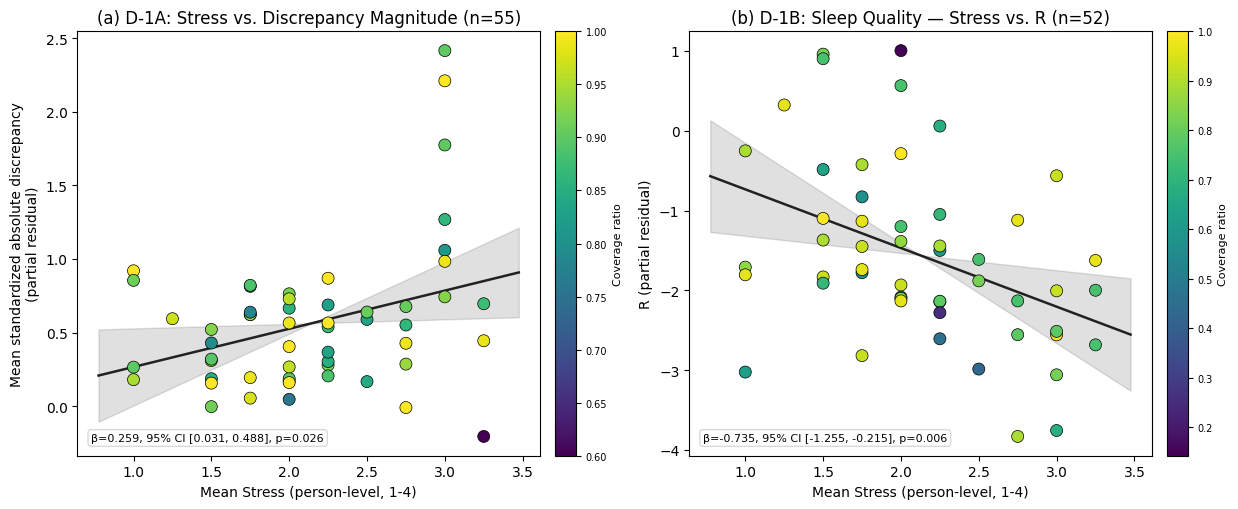


Figure 2 저장 완료: results/figure2_stress_discrepancy.png


In [46]:
import matplotlib.pyplot as plt

def fit_cluster_ols(data, dv, predictor):
    d = data.dropna(subset=[dv, 'gender', 'coverage_ratio', predictor]).copy()
    d['gender'] = d['gender'].astype(int).astype('category')
    formula = f"{dv} ~ C(indicator) + C(gender) + coverage_ratio + {predictor}"
    res = smf.ols(formula, d).fit(cov_type='cluster', cov_kwds={'groups': d['id']})
    d['_fitted'] = res.fittedvalues
    coef = res.params[predictor]
    ci = res.conf_int().loc[predictor]
    p = res.pvalues[predictor]
    d['_pr'] = (d[dv] - d['_fitted']) + coef * d[predictor]
    return res, d, coef, tuple(ci), p

def fit_hc3(data, dv, predictor):
    d = data.dropna(subset=[dv, 'gender', 'coverage_ratio', predictor]).copy()
    d['gender'] = d['gender'].astype(int).astype('category')
    formula = f"{dv} ~ coverage_ratio + C(gender) + {predictor}"
    res = smf.ols(formula, d).fit(cov_type='HC3')
    d['_fitted'] = res.fittedvalues
    coef = res.params[predictor]
    ci = res.conf_int().loc[predictor]
    p = res.pvalues[predictor]
    d['_pr'] = (d[dv] - d['_fitted']) + coef * d[predictor]
    return res, d, coef, tuple(ci), p

# ---------- (a) D-1A: mean_stress -> |D*| (cluster-robust OLS) ----------
res_a, d_a, coef_a, ci_a, p_a = fit_cluster_ols(d1a, 'absD_star', 'mean_stress')
person_a = d_a.groupby('id').agg(pr=('_pr', 'mean'), x=('mean_stress', 'first'),
                                   coverage=('coverage_ratio', 'mean')).reset_index()
print(f"[Figure2 (a) D-1A] n={len(person_a)}, coef={coef_a:.4f}, 95%CI={ci_a}, p={p_a:.4f}")

# ---------- (b) D-1B 수면질: mean_stress -> R (HC3 OLS) ----------
sub_sleepq = d1b[d1b['indicator'] == '수면질']
res_b, d_b, coef_b, ci_b, p_b = fit_hc3(sub_sleepq, 'R', 'mean_stress')
print(f"[Figure2 (b) D-1B 수면질] n={len(d_b)}, coef={coef_b:.4f}, 95%CI={ci_b}, p={p_b:.4f}")

# ---------- 플롯 ----------
def draw_line(ax, x, y, coef, ci):
    anchor_x, anchor_y = x.mean(), y.mean()
    xs = np.linspace(x.min() - 0.1 * (x.max() - x.min() + 1e-9), x.max() + 0.1 * (x.max() - x.min() + 1e-9), 50)
    ys_mid = anchor_y + coef * (xs - anchor_x)
    ys_lo = anchor_y + ci[0] * (xs - anchor_x)
    ys_hi = anchor_y + ci[1] * (xs - anchor_x)
    ax.fill_between(xs, ys_lo, ys_hi, color='black', alpha=0.12)
    ax.plot(xs, ys_mid, linestyle='-', linewidth=1.8, color='black', alpha=0.85, zorder=3)

def scatter_with_colorbar(ax, x, y, cov, vmin, vmax):
    sc = ax.scatter(x, y, c=cov, cmap='viridis', vmin=vmin, vmax=vmax, s=75,
                     edgecolors='k', linewidths=0.5, zorder=4)
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label('Coverage ratio', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

ax = axes[0]
draw_line(ax, person_a['x'], person_a['pr'], coef_a, ci_a)
scatter_with_colorbar(ax, person_a['x'], person_a['pr'], person_a['coverage'],
                       person_a['coverage'].min(), person_a['coverage'].max())
ax.set_xlabel('Mean Stress (person-level, 1-4)')
ax.set_ylabel('Mean standardized absolute discrepancy\n(partial residual)')
ax.set_title(f"(a) D-1A: Stress vs. Discrepancy Magnitude (n={len(person_a)})")
ax.text(0.03, 0.03, f"β={coef_a:.3f}, 95% CI [{ci_a[0]:.3f}, {ci_a[1]:.3f}], p={p_a:.3f}",
        transform=ax.transAxes, fontsize=8, va='bottom', ha='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='lightgray'))

ax = axes[1]
draw_line(ax, d_b['mean_stress'], d_b['_pr'], coef_b, ci_b)
scatter_with_colorbar(ax, d_b['mean_stress'], d_b['_pr'], d_b['coverage_ratio'],
                       d_b['coverage_ratio'].min(), d_b['coverage_ratio'].max())
ax.set_xlabel('Mean Stress (person-level, 1-4)')
ax.set_ylabel('R (partial residual)')
ax.set_title(f"(b) D-1B: Sleep Quality — Stress vs. R (n={len(d_b)})")
ax.text(0.03, 0.03, f"β={coef_b:.3f}, 95% CI [{ci_b[0]:.3f}, {ci_b[1]:.3f}], p={p_b:.3f}",
        transform=ax.transAxes, fontsize=8, va='bottom', ha='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='lightgray'))

plt.tight_layout()
plt.savefig('results/figure2_stress_discrepancy.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 2 저장 완료: results/figure2_stress_discrepancy.png")


## Figure 1: 걷기빈도 및 주중 수면시간의 자기보고-웨어러블 산점도

Table 2의 방법 간 일치도·편향 분석 표본(걷기빈도 n=55, 주중 수면시간 n=56)과 동일한 person-level 대표값을 사용한다. 위 '분석 데이터셋 구축' 단계에서 이미 계산한 `person_datasets['걷기빈도']`/`person_datasets['주중_수면시간']`을 그대로 재사용하며, 점선은 완전일치(y=x)를 나타낸다.


걷기빈도 n = 55
주중 수면시간 n = 56


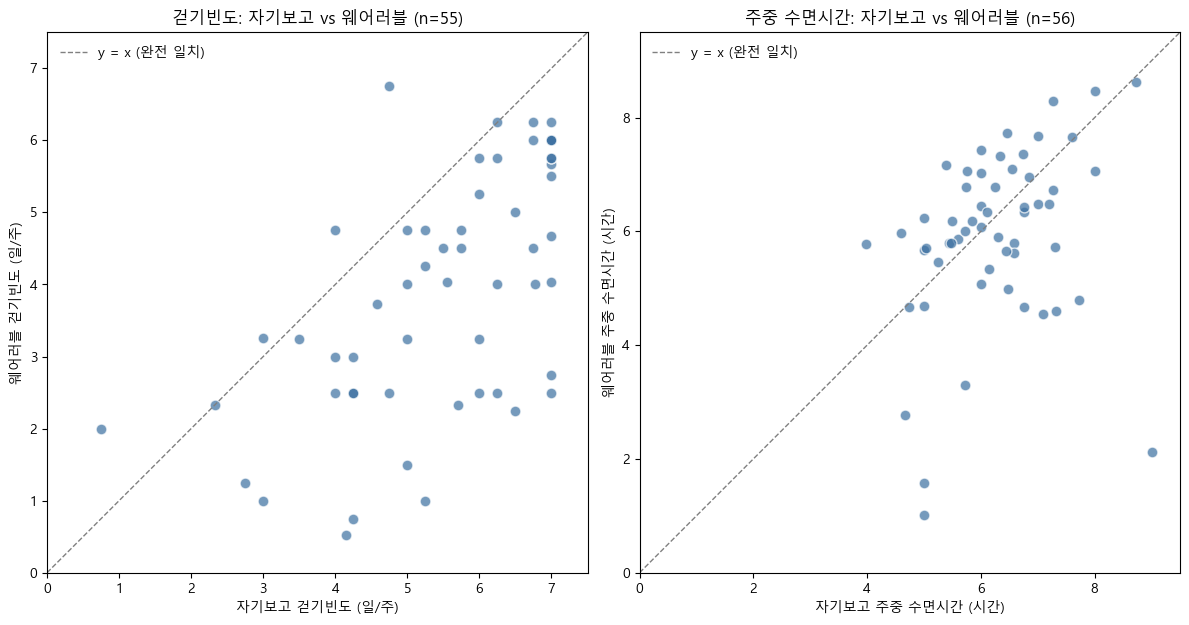


Figure 1 저장 완료: results/figure1_eda_scatter_walkfreq_sleep.png


In [47]:
import matplotlib
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

person_walk = person_datasets['걷기빈도']
person_sleep = person_datasets['주중_수면시간']

print(f'걷기빈도 n = {len(person_walk)}')
print(f'주중 수면시간 n = {len(person_sleep)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

panels = [
    (axes[0], person_walk, '걷기빈도 (일/주)', f'걷기빈도: 자기보고 vs 웨어러블 (n={len(person_walk)})'),
    (axes[1], person_sleep, '주중 수면시간 (시간)', f'주중 수면시간: 자기보고 vs 웨어러블 (n={len(person_sleep)})'),
]

for ax, person, axis_label, title in panels:
    lim_max = max(person['survey_value'].max(), person['wearable_value'].max()) + 0.5
    ax.plot([0, lim_max], [0, lim_max], linestyle='--', color='gray', linewidth=1, label='y = x (완전 일치)')
    ax.scatter(person['survey_value'], person['wearable_value'], alpha=0.7, color='#3b6fa0', edgecolor='white', s=60)
    ax.set_xlabel(f'자기보고 {axis_label}')
    ax.set_ylabel(f'웨어러블 {axis_label}')
    ax.set_xlim(0, lim_max)
    ax.set_ylim(0, lim_max)
    ax.set_aspect('equal')
    ax.legend(loc='upper left', frameon=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('results/figure1_eda_scatter_walkfreq_sleep.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nFigure 1 저장 완료: results/figure1_eda_scatter_walkfreq_sleep.png")
